# Software Evolution - Bots and Roles in GitHub Projects

The objective of this lab session is to get hands-on experience with automated agents (**bots**) in two real-world open-source projects from the **NumFocus** community (https://numfocus.org) whose mission is to promote open practices in scientific computing through open source projects. By analysing GitHub event data on NumFocus project repositories, applying machine‑learning‑based bot detection and categorising contributors by their activities, you will uncover how bots and humans collaborate and how their behaviors differ.

## 🎯 Learning Objectives

By the end of this practical, you will be able to:

- **Explore and summarise** GitHub event data using Python (pandas, matplotlib).
- **Detect bot accounts** with **RABBIT**, an offline bot identification tool based on behavioral patterns.
- **Assign behavioral roles** (developer, reviewer, merger, reporter, commenter) to contributors using activity sequences.
- **Compare bot vs. human activity** within a project and between two different projects.
- **Visualise** distributions and patterns (bar charts, box plots, heatmaps).
- **Apply statistical tests** (Mann‑Whitney U, Shapiro-Wilk) to validate observed differences.
- **Interpret results** and draw evidence‑based conclusions about software development automation.

## 📂 Data Provided

You have been assigned a **folder number** (01-18). Inside that folder you will find:

- **`Project-Events/`**  
  Contains two JSON files, one per project (e.g., `numpy_numpy.json`, `cupy_cupy.json`).  
  Each file holds raw GitHub events for that project (fields like `type`, `actor`, `created_at`, etc.).  
  *Used for initial exploration and to identify contributors.*

- **`Contributor-Events/`**  
  Contains one JSON file per contributor (e.g., `dependabot[bot].json`).  
  Each file includes the last 300 events of that contributor across all NumFocus projects (not only the two target projects).  
  *Used as input for RABBIT’s offline bot detection.*

- **`Project-Activities/`**  
  Contains JSON Lines files (`cupy_cupy.jsonl`, `numpy_numpy.jsonl`) with pre‑computed *activities* (aggregated from events).  
  Each line represents a structured activity (e.g., `OpenIssue`, `ReviewPullRequest`) with start/end dates, actor, repository and low‑level actions.  
  *Used for role assignment.*

> **Note:** The data have been pre‑processed to remove any sensitive information and to ensure consistency across students.

## 🧰 Required Tools & Libraries

Make sure you have a working Python 3 environment (≥3.8) and JupyterLab installed. All necessary packages are listed in `requirements.txt`. The notebook will automatically install them when you run the first cell.

Key libraries you will use:

- **pandas**, **numpy**, data manipulation  
- **matplotlib**, **seaborn**, visualisation  
- **scipy.stats**, statistical tests (Mann‑Whitney U, Shapiro-Wilk)  
- **RABBIT**, offline bot detection (installed via GitHub)  
- **`roles` module**, custom role assignment (provided in the repository)

## 📝 How to Work with This Notebook

- **Code cells** marked with `# TODO` require you to complete a few lines of code. Read the instructions carefully.
- **Markdown cells** contain questions for you to answer. Write your answers in the cell directly below the question. Use clear reasoning and, where appropriate, refer to the visualisations or tables you have generated.
- The notebook is designed to be **self‑contained**: run cells in order and all outputs (dataframes, plots) will appear inline.
- At the end of each section, there are **reflection questions** that help you synthesise what you have learned. These will be part of your final evaluation.
- **Set your folder number** in the first code cell of Section 1, this is the only manual change required.

## 📌 Outline of the Practical

| Section | Title | What You Will Do |
|---------|-------|------------------|
| 1 | **Setup & Data Exploration** | Load project events, summarise them, identify contributors and visualise activity patterns. |
| 2 | **Bot Detection with RABBIT** | Run RABBIT on contributor events, analyse predictions, manually validate samples and merge bot labels with project data. |
| 3 | **Contributor Role Categorisation** | Load activity sequences, assign roles (developer, reviewer, etc.) and explore role distributions. Merge with bot labels to compare bots vs. humans. |
| 4 | **Comparative Behavioral Analysis** | Compare the two projects side‑by‑side, test for statistical significance and draw conclusions about bot usage and collaboration patterns. |

Each section contains **explanations** of the underlying concepts, links to further reading and step‑by‑step instructions.

## 🧪 Evaluation Criteria

Your work will be assessed on:

- Correct execution of the code (no errors, meaningful outputs).
- Completeness of answers to reflection questions.
- Quality of visualisations and interpretations.
- Insightful discussion of differences between projects and between bots and humans.
- Proper use of statistical tests and interpretation of p‑values and effect sizes.

Make sure to **save your notebook frequently** and to **keep all outputs visible** (do not clear them before submission).

## Section 1: Setup & Data Exploration

In this first section, you will get familiar with the dataset. You will learn about the structure of GitHub events, load two projects, compute basic statistics and visualise activity patterns. This foundation will be essential for the bot detection and role analysis that follow.

### 1.1. Environment Preparation

We begin by installing and importing the required libraries. Run the cells below. If you are using a fresh environment, the installations may take a minute.

In [2]:
%pip -q install --upgrade pip
%pip -q install seaborn
%pip -q install scipy
%pip -q install rabbit-ng

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


*Note: After installation, you may need to restart the kernel to use the updated packages. If you see a warning, simply restart the kernel and run the cells again.*

In [3]:
# Import standard libraries for data manipulation and visualisation
import pandas as pd
import numpy as np
import json
from pathlib import Path
from datetime import datetime, timezone

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

Each student has been assigned a specific dataset folder (numbered 01 to 18). **Replace the placeholder below with your folder number** (e.g., `'03'`). Then we define the paths to the data.

In [4]:
# TODO: Replace with your assigned folder number (e.g., '01', '02', ..., '18')
YOUR_FOLDER_NUMBER = '06'   # <-- CHANGED :)

# Define paths based on your folder number
DATA_BASE_PATH = Path('data') / YOUR_FOLDER_NUMBER
PROJECT_EVENTS_PATH = DATA_BASE_PATH / 'Project-Events'
CONTRIBUTOR_EVENTS_PATH = DATA_BASE_PATH / 'Contributor-Events'

# Display the folder structure to verify
print("📁 Your data structure:")
print(f"Project Events folder: {PROJECT_EVENTS_PATH}")
print(f"Contributor Events folder: {CONTRIBUTOR_EVENTS_PATH}")
print(f"Files in Project-Events: {list(PROJECT_EVENTS_PATH.glob('*.json'))}")
print(f"Number of contributor files: {len(list(CONTRIBUTOR_EVENTS_PATH.glob('*.json')))}")

📁 Your data structure:
Project Events folder: data/06/Project-Events
Contributor Events folder: data/06/Contributor-Events
Files in Project-Events: [PosixPath('data/06/Project-Events/jump-dev_JuMP.jl.json'), PosixPath('data/06/Project-Events/sunpy_sunpy.json')]
Number of contributor files: 132


### 1.2. Loading the Project Pair

We will now load the two project event files. The function `load_project_events` reads a JSON file, normalises the nested structure and converts timestamps to proper datetime objects.

In [5]:
def load_project_events(project_path):
    """
    Load and parse a project's event JSON file.
    
    Args:
        project_path: Path to the JSON file containing project events
        
    Returns:
        pandas.DataFrame: DataFrame containing project events
    """
    with open(project_path, 'r') as f:
        events_data = json.load(f)
    
    # Convert to DataFrame
    df = pd.json_normalize(events_data)
    
    # Parse timestamps from milliseconds to datetime
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
    
    return df

Now load both projects:

In [6]:
project_files = list(PROJECT_EVENTS_PATH.glob('*.json'))
project_dfs = {}

print("📊 Loading project data...")
for project_file in project_files:
    project_name = project_file.stem  # Remove .json extension
    project_dfs[project_name] = load_project_events(project_file)
    print(f"  - {project_name}: {len(project_dfs[project_name])} events loaded")

# Store project names for easy reference
PROJECT_1_NAME = list(project_dfs.keys())[0]
PROJECT_2_NAME = list(project_dfs.keys())[1]

print(f"\n✅ Projects loaded: {PROJECT_1_NAME} and {PROJECT_2_NAME}")

print(project_dfs.keys())
print(project_dfs[PROJECT_1_NAME])
print("\n-----------------------------\n")
print(project_dfs[PROJECT_2_NAME])
print(project_dfs)

📊 Loading project data...
  - jump-dev_JuMP.jl: 1092 events loaded
  - sunpy_sunpy: 1186 events loaded

✅ Projects loaded: jump-dev_JuMP.jl and sunpy_sunpy
dict_keys(['jump-dev_JuMP.jl', 'sunpy_sunpy'])
                               type  public  \
0                 IssueCommentEvent    True   
1                       IssuesEvent    True   
2                        WatchEvent    True   
3                 IssueCommentEvent    True   
4                       IssuesEvent    True   
...                             ...     ...   
1087  PullRequestReviewCommentEvent    True   
1088                      PushEvent    True   
1089               PullRequestEvent    True   
1090                    CreateEvent    True   
1091              IssueCommentEvent    True   

                                                payload          created_at  \
0     {"action":"created","issue":{"url":"https://ap... 2024-11-29 20:40:56   
1     {"action":"closed","issue":{"url":"https://api... 2024-11-29 20:40:5

**Question 1.1:**  
Inspect the project_dfs dictionary containing the extracted data for both projects. How many events does each project have? Which project has a longer time span? Write your answer below.

The first project has 1092 events and the second 1186. (plus 1 because events start at index 0).
The first project has a longer time span because the first event is a creation of an issue. Conversely, at the same time, the second project was created({"action":"started"} 2024-09-01 00:04:58). But the summary below says its the second project which has a longer time span.

Let's compute a quick summary for each project: total events, number of unique contributors, distinct event types, time range and duration in days.

In [7]:
def summarise_project(df, project_name):
    """Generate basic statistics for a project."""
    summary = {
        'Project': project_name,
        'Total Events': len(df),
        'Unique Contributors': df['actor.login'].nunique(),
        'Event Types': df['type'].nunique(),
        'Time Range': f"{df['created_at'].min().date()} to {df['created_at'].max().date()}",
        'Duration (days)': (df['created_at'].max() - df['created_at'].min()).days
    }
    return summary

# Create summary for both projects
summary_data = []
for project_name, df in project_dfs.items():
    summary_data.append(summarise_project(df, project_name))

# Display as a nice table
summary_df = pd.DataFrame(summary_data)
print("📈 Project Overview:")
display(summary_df)

📈 Project Overview:


,Project,Total Events,Unique Contributors,Event Types,Time Range,Duration (days)
0,jump-dev_JuMP.jl,1092,79,12,2024-09-01 to 2024-11-29,89
1,sunpy_sunpy,1186,54,11,2024-09-01 to 2024-11-30,90


**Question 1.2:**  
Compare the two projects. Which one has more contributors? Which one has a longer duration? What might this tell you about the activity level of each project?

The first project has more contributors (79 vs 54). The second project has a longer duration (90 vs 89). The activity level of the first project is relatively moderate: there is a lot of contributors but less events than the second project. Conversely, the second project has a lot of events and less contributors. There are more involved.

### 1.3. First Look: Event Types & Contributors

GitHub events come in many types (e.g., `IssueCommentEvent`, `PushEvent`). To simplify analysis, we group them into four broad categories:

- **Issues**: `IssuesEvent`, `IssueCommentEvent`
- **Pull Requests**: `PullRequestEvent`, `PullRequestReviewEvent`, `PullRequestReviewCommentEvent`
- **Commits**: `PushEvent`, `CommitCommentEvent`
- **Repository**: `CreateEvent`, `DeleteEvent`, `ForkEvent`, `WatchEvent`, `ReleaseEvent`, `PublicEvent`

We'll add a new column `event_category` to each DataFrame.

In [8]:
def analyse_event_types(df, project_name):
    """Analyse the distribution of event types in a project."""
    # Count event types
    event_counts = df['type'].value_counts().reset_index()
    event_counts.columns = ['Event Type', 'Count']
    event_counts['Percentage'] = (event_counts['Count'] / len(df) * 100).round(1)
    
    # Group similar events into categories
    event_categories = {
        'Issues': ['IssuesEvent', 'IssueCommentEvent'],
        'Pull Requests': ['PullRequestEvent', 'PullRequestReviewEvent', 'PullRequestReviewCommentEvent'],
        'Commits': ['PushEvent', 'CommitCommentEvent'],
        'Repository': ['CreateEvent', 'DeleteEvent', 'ForkEvent', 'WatchEvent', 'ReleaseEvent', 'PublicEvent'],
        'Other': []  # Everything else
    }
    
    # TODO: Define a function that assigns a category to a given event type.
    # The function should return the category name if the event type matches any of the lists,
    # otherwise return 'Other'.
    def categorise_event(event_type):
        # Your code here (2-4 lines)
        for category, events in event_categories.items():
            if event_type in events:
                return category
        return 'Other'
        
    
    df['event_category'] = df['type'].apply(categorise_event)
    
    return event_counts, df

**TODO 1.1:** Complete the function `categorise_event` inside the cell above. It should loop through the `event_categories` dictionary and return the category name if the `event_type` is found in the corresponding list; otherwise return `'Other'`.  

After you have written the function, run the next cell to apply it to both projects.

In [9]:
# Analyse event types for both projects
for project_name, df in project_dfs.items():
    event_counts, project_dfs[project_name] = analyse_event_types(df, project_name)
    
    print(f"\n🎯 Event Distribution for {project_name}:")
    print("-" * 40)
    print(f"Total unique event types: {len(event_counts)}")
    
    # Display top 10 event types
    print("\nTop 10 Event Types:")
    display(event_counts.head(10))
    
    # Quick category breakdown
    category_counts = project_dfs[project_name]['event_category'].value_counts()
    print("\n📊 Event Categories:")
    for category, count in category_counts.items():
        percentage = (count / len(df) * 100)
        print(f"  - {category}: {count} events ({percentage:.1f}%)")


🎯 Event Distribution for jump-dev_JuMP.jl:
----------------------------------------
Total unique event types: 12

Top 10 Event Types:


,Event Type,Count,Percentage
0,PushEvent,413,37.8
1,IssueCommentEvent,159,14.6
2,PullRequestEvent,129,11.8
3,PullRequestReviewEvent,91,8.3
4,PullRequestReviewCommentEvent,77,7.1
5,CreateEvent,63,5.8
6,DeleteEvent,60,5.5
7,WatchEvent,57,5.2
8,IssuesEvent,26,2.4
9,CommitCommentEvent,8,0.7



📊 Event Categories:
  - Commits: 421 events (38.6%)
  - Pull Requests: 297 events (27.2%)
  - Repository: 189 events (17.3%)
  - Issues: 185 events (16.9%)

🎯 Event Distribution for sunpy_sunpy:
----------------------------------------
Total unique event types: 11

Top 10 Event Types:


,Event Type,Count,Percentage
0,PullRequestReviewEvent,335,28.2
1,PullRequestReviewCommentEvent,331,27.9
2,IssueCommentEvent,197,16.6
3,PullRequestEvent,155,13.1
4,PushEvent,78,6.6
5,IssuesEvent,29,2.4
6,WatchEvent,20,1.7
7,CreateEvent,14,1.2
8,DeleteEvent,13,1.1
9,ForkEvent,12,1.0



📊 Event Categories:
  - Pull Requests: 821 events (69.2%)
  - Issues: 226 events (19.1%)
  - Commits: 78 events (6.6%)
  - Repository: 61 events (5.1%)


**Question 1.3:**  
Look at the category breakdown for both projects. Which category dominates in the first project? In the second project? What does this suggest about the main activities in each project (e.g., issue discussion, code review, repository maintenance)?

In the first project, the dominant category is the Commits. In the second project, it's the PullRequest. In the first project, developers push code regurlaly. In the second project, there is more code reviewing before the code is pushed. 

Now let's identify the most active contributors. We'll compute the total number of events per contributor and the duration of their activity (first to last event).

In [10]:
def analyse_contributors(df, project_name, top_n=15):
    """Analyse contributor activity patterns."""
    # Get contributor activity counts
    contributor_stats = df.groupby('actor.login').agg({
        'type': 'count',
        'event_category': lambda x: x.value_counts().to_dict(),
        'created_at': ['min', 'max']
    }).reset_index()
    
    # Flatten column names
    contributor_stats.columns = ['contributor', 'total_events', 'category_distribution', 'first_activity', 'last_activity']
    
    # Calculate activity duration
    contributor_stats['activity_duration_days'] = (
        contributor_stats['last_activity'] - contributor_stats['first_activity']
    ).dt.days
    
    # Sort by total events
    contributor_stats = contributor_stats.sort_values('total_events', ascending=False)
    
    print(f"\n👥 Contributor Analysis for {project_name}:")
    print("-" * 50)
    print(f"Total unique contributors: {len(contributor_stats)}")
    print(f"Top {top_n} most active contributors:")
    
    # Display top contributors
    display(contributor_stats[['contributor', 'total_events', 'activity_duration_days']].head(top_n))
    
    return contributor_stats

# Analyse contributors for both projects
contributor_stats = {}
for project_name, df in project_dfs.items():
    contributor_stats[project_name] = analyse_contributors(df, project_name)


👥 Contributor Analysis for jump-dev_JuMP.jl:
--------------------------------------------------
Total unique contributors: 79
Top 15 most active contributors:


,contributor,total_events,activity_duration_days
60,odow,779,88
39,github-actions[bot],61,85
26,codecov[bot],58,84
24,blegat,32,86
47,joaquimg,27,60
38,gdalle,17,10
45,jd-foster,15,71
74,wsmoses,12,10
51,langestefan,6,39
9,JuliaRegistrator,4,67



👥 Contributor Analysis for sunpy_sunpy:
--------------------------------------------------
Total unique contributors: 54
Top 15 most active contributors:


,contributor,total_events,activity_duration_days
41,nabobalis,558,90
0,Cadair,162,86
44,raghav20232023,65,1
9,Prtm2110,58,81
53,wtbarnes,56,78
24,ayshih,51,57
3,GillySpace27,32,46
11,Sauravroy34,21,80
32,github-actions[bot],21,70
49,tien-vo,21,13


**Question 1.4:**  
Look at the top contributors in each project. Do you notice any usernames that end with `[bot]`? Which project seems to have more bot‑like accounts among the most active? Write your observations.

Yes, I can notice some usernames that end with [bot]. For instance, github-actions[bot] and codecov[bot]. The first project seems to have more bot-like accounts among the most active. Indeed, in the top-3 contributors, at least two are have the suffix [bot]. Moreover, we can notice that for the both projects, there is a "super" contributor with a huge ammount of events compared to the others. But now, we don't know if there are bots or not.

Finally, we visualise how activity evolved over time. The plots below show daily event counts and the distribution of event categories.


--- jump-dev_JuMP.jl ---
created_at
Monday       142
Tuesday      220
Wednesday    257
Thursday     226
Friday       178
Saturday      24
Sunday        45
Name: count, dtype: int64

--- sunpy_sunpy ---
created_at
Monday       220
Tuesday      320
Wednesday    236
Thursday     217
Friday       111
Saturday      41
Sunday        41
Name: count, dtype: int64


/tmp/ipykernel_17469/2758729353.py:51: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gaxs/Documents/S4/Software Evolution/TP3/Software-Evolution-Practical-Bots/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


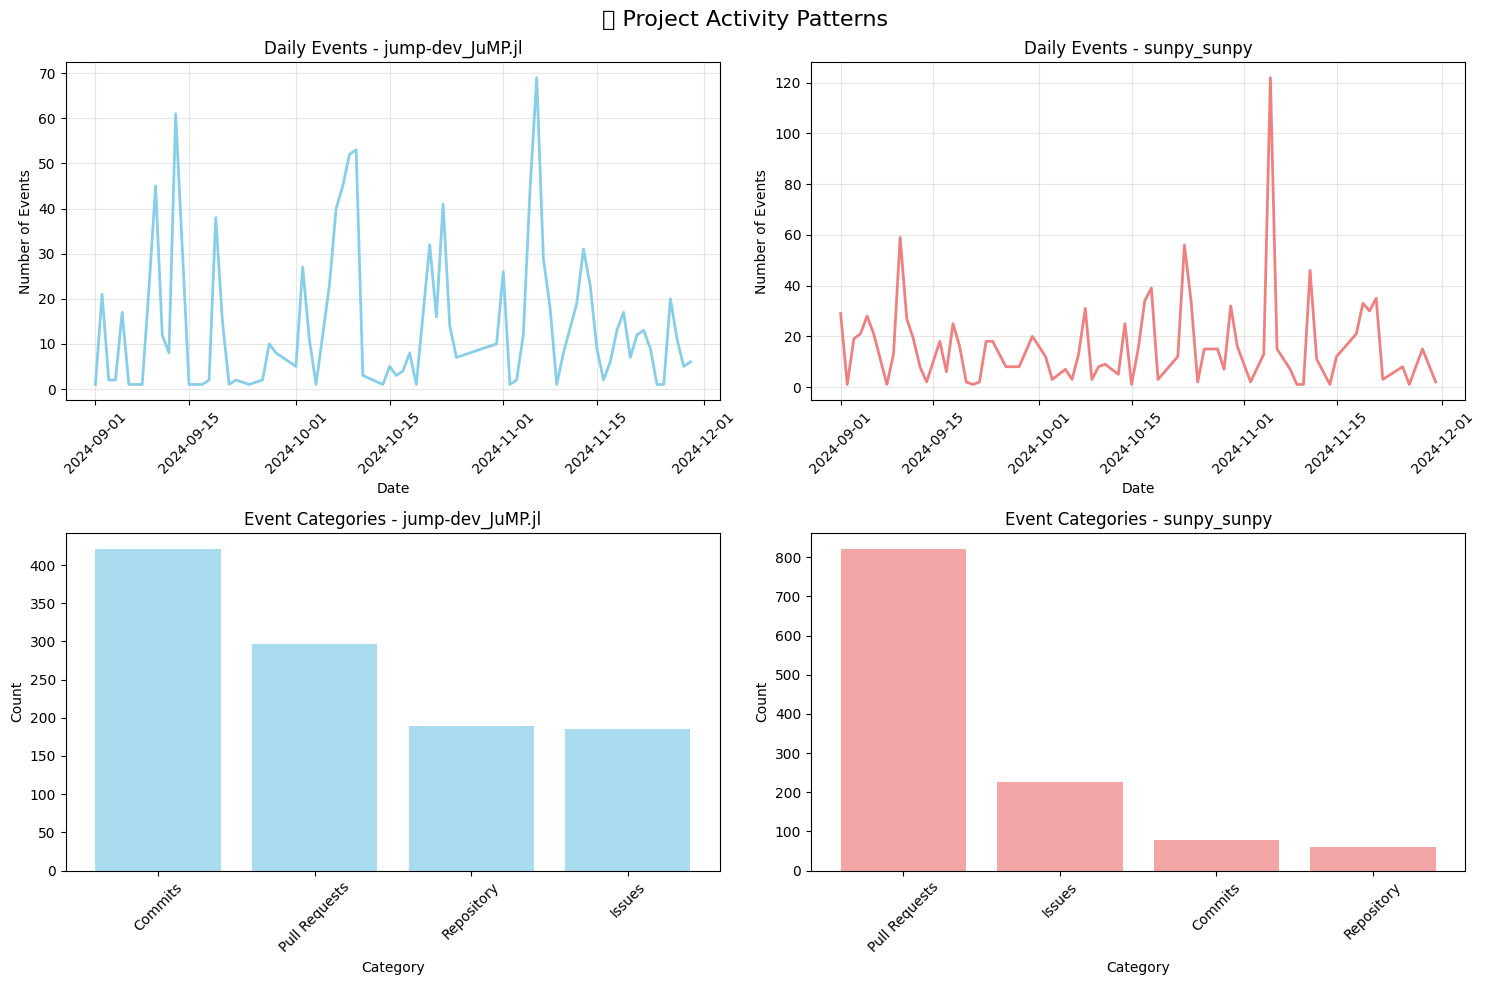

In [11]:
# Set up the visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📈 Project Activity Patterns', fontsize=16)

# Plot 1: Daily event counts for Project 1
project1_df = project_dfs[PROJECT_1_NAME]
daily_counts_1 = project1_df.groupby(project1_df['created_at'].dt.date).size()
axes[0, 0].plot(daily_counts_1.index, daily_counts_1.values, color='skyblue', linewidth=2)
axes[0, 0].set_title(f'Daily Events - {PROJECT_1_NAME}')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Events')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Daily event counts for Project 2
project2_df = project_dfs[PROJECT_2_NAME]
daily_counts_2 = project2_df.groupby(project2_df['created_at'].dt.date).size()
axes[0, 1].plot(daily_counts_2.index, daily_counts_2.values, color='lightcoral', linewidth=2)
axes[0, 1].set_title(f'Daily Events - {PROJECT_2_NAME}')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Number of Events')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Event type distribution for Project 1
event_counts_1 = project1_df['event_category'].value_counts()
axes[1, 0].bar(event_counts_1.index, event_counts_1.values, color='skyblue', alpha=0.7)
axes[1, 0].set_title(f'Event Categories - {PROJECT_1_NAME}')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Event type distribution for Project 2
event_counts_2 = project2_df['event_category'].value_counts()
axes[1, 1].bar(event_counts_2.index, event_counts_2.values, color='lightcoral', alpha=0.7)
axes[1, 1].set_title(f'Event Categories - {PROJECT_2_NAME}')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# WEEKEND ANALYSIS
for project_name, df in project_dfs.items():
    print(f"\n--- {project_name} ---")
    
    day_counts = df['created_at'].dt.day_name().value_counts()
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = day_counts.reindex(days_order)
    
    print(day_counts)

plt.tight_layout()
plt.show()

**Question 1.5:**  
Look at the daily activity plots. Are there any spikes or patterns that might indicate automated (bot) activity? For example, very regular peaks or activity on weekends? Write your observations.

Yes, there is a significant spike in the second project. But otherwise, we cannot conclude that there are bots. On the contrary, in the first project, there are periodic spikes. This may be due to bots. As for weekends, in the first project, there are a few events on Sundays, so these may be automatic events (launched by bots). In the second project, there are the same number of events the Sundays and Saturdays, so this may also be due to bots.

## Section 2: Bot Detection with RABBIT

In this section, we will use **RABBIT** (Activity-Based Bot Identification Tool) to automatically classify contributors as **Bots** or **Humans** based on their behavioral patterns. RABBIT analyses sequences of GitHub events using a machine learning model trained on 38 different behavioral features (e.g., time between events, types of actions, repetition). It works in **offline mode**, we already have all the event data, so no API calls are needed.

> 📚 **Background**: RABBIT is based on the BIMBAS model developed by Chidambaram et al. (2025). You can read more in the [RABBIT GitHub repository](https://github.com/sgl-umons/RABBIT-ng). The model outputs a `user_type` (`Bot` or `Human`) and a `confidence` score between 0 and 1.

First, let's check what contributor event files are available. Each file corresponds to a single contributor and contains their last 300 events across all NumFocus projects.

In [12]:
# First, let's check what contributor event data we have
print("📂 Loading contributor event files...")
contributor_files = list(CONTRIBUTOR_EVENTS_PATH.glob("*.json"))
print(f"Found {len(contributor_files)} contributor event files")
print("Sample contributor names:", [f.stem for f in contributor_files[:5]])

📂 Loading contributor event files...
Found 132 contributor event files
Sample contributor names: ['Fe-r-oz', 'QuantPaul', 'dong123-wang', 'aditya-mathpal', 'sstroemer']


### 2.1. Running RABBIT on Contributor-Events

RABBIT can work in offline mode, which means we don't need to make any API calls to GitHub. We already have all the event data we need in our JSON files. This makes the analysis faster and doesn't require API tokens.It provides an `ONNXPredictor` class that loads a pre‑trained model. We'll initialise it now.

In [13]:
# Import RABBIT's offline components
from rabbit_ng.predictor import ONNXPredictor, predict_user_type

print("🤖 Initialising RABBIT predictor...")
# This loads the pre-trained machine learning model
predictor = ONNXPredictor()
print("✅ RABBIT predictor loaded successfully!")

🤖 Initialising RABBIT predictor...
✅ RABBIT predictor loaded successfully!


We also need a helper function to load events for a given contributor from its JSON file.

In [14]:
def load_contributor_events(contributor_name):
    """
    Load event data for a single contributor.
    
    Args:
        contributor_name: The GitHub username of the contributor
        
    Returns:
        list: A list of event dictionaries in the format RABBIT expects
    """
    file_path = CONTRIBUTOR_EVENTS_PATH / f"{contributor_name}.json"
    if file_path.exists():
        with open(file_path, 'r') as f:
            events = json.load(f)
        
        for ev in events:
            if isinstance(ev.get('created_at'), (int, float)):
                dt = datetime.fromtimestamp(ev['created_at'] / 1000.0, tz=timezone.utc)
                ev['created_at'] = dt.strftime('%Y-%m-%dT%H:%M:%SZ')
        
        return events
    else:
        print(f"⚠️ Warning: No event file found for {contributor_name}")
        return []

Let's test with one contributor

In [15]:
test_contributor = list(CONTRIBUTOR_EVENTS_PATH.glob("*.json"))[0].stem
test_events = load_contributor_events(test_contributor)
print(f"\n📊 Sample data for {test_contributor}:")
print(f"  - Number of events: {len(test_events)}")
print(f"  - Event types found: {set(event['type'] for event in test_events[:5])}")


📊 Sample data for Fe-r-oz:
  - Number of events: 8
  - Event types found: {'WatchEvent'}


Now we will run RABBIT on every contributor. The function below already includes a simple heuristic: if a username ends with `[bot]`, we classify it as a bot with confidence 1.0 without running the model (this saves time and leverages GitHub's own labeling).

**TODO 2.2:** Inside the function `run_rabbit_on_all_contributors`, there are 3 missing parts:
- Auto-classify as `'Bot'` with confidence `1.0` if username ends with `[bot]`.
- If a contributor has fewer than 5 events, mark them as `'Unknown'` with confidence `0.0`.
- Run RABBIT by calling `predict_user_type()` and store the result.

Fill in the code where indicated by `# TODO:`.

In [16]:
def run_rabbit_on_all_contributors():
    """
    Run RABBIT's offline prediction on all contributors.
    Contributors with '[bot]' suffix are auto-classified as Bot (confidence 1.0).
    
    Returns:
        pandas.DataFrame: DataFrame with columns contributor, rabbit_type, confidence
    """
    results = []
    
    print("🚀 Starting RABBIT analysis...")
    print("Processing contributors:", end=" ")
    
    contributor_files = list(CONTRIBUTOR_EVENTS_PATH.glob("*.json"))
        
    for file_path in contributor_files:
        contributor = file_path.stem
        
        # Auto-classify if username ends with [bot]
        if contributor.endswith('[bot]'):
            # TODO: Append Bot result with confidence 1.0 and continue
            # Your code here...
            results.append({
                'contributor': contributor,
                'rabbit_type': 'Bot',
                'confidence': 1.0
            })
            
            continue
        
        # Load events
        events = load_contributor_events(contributor)
        
        if len(events) < 5:
            # TODO: Append Unknown result with confidence 0.0 and continue
            # Your code here...
            results.append({
                'contributor': contributor,
                'rabbit_type': 'Unknown',
                'confidence': 0.0
            })
            continue
        
        # Run RABBIT prediction
        try:
            # TODO: Call predict_user_type() and append the result
            # Your code here...
            result = predict_user_type(contributor, events, predictor)
            results.append({
                'contributor': contributor,
                'rabbit_type': result.user_type,
                'confidence': result.confidence
            })
            
        except Exception as e:
            print(f"\n❌ Error processing {contributor}: {e}")
            results.append({
                'contributor': contributor,
                'rabbit_type': 'Error',
                'confidence': 0.0
            })
    
    return pd.DataFrame(results)

# Run the analysis (this may take a minute or two)
rabbit_predictions = run_rabbit_on_all_contributors()

print("\n" + "="*60)
print("🎯 RABBIT ANALYSIS COMPLETE")
print("="*60)
display(rabbit_predictions.head(10))

🚀 Starting RABBIT analysis...
Processing contributors: 
🎯 RABBIT ANALYSIS COMPLETE


,contributor,rabbit_type,confidence
0,Fe-r-oz,Bot,0.096
1,QuantPaul,Human,0.784
2,dong123-wang,Unknown,0.000
3,aditya-mathpal,Unknown,0.000
4,sstroemer,Human,0.771
5,wmoapl,Bot,0.311
6,Riperedo,Unknown,0.000
7,csamuelsm,Unknown,0.000
8,songroom2016,Unknown,0.000
9,audiofacto,Unknown,0.000


**Question 2.2:**  
Look at the first few rows of `rabbit_predictions`. What do you notice about the confidence scores? Are they generally high or low? Why might that be?

The confidence scores are pretty low ! I think it is because the contributors have not enough events. We have seen in the previous section that the contributors have on average 10 to 30 events. It is not enough to determine if there are humans or bots with a high certitude.

### 2.2. Interpreting Bot/Human Predictions

We now analyse the RABBIT predictions. The following function generates a summary.

In [17]:
def analyse_rabbit_predictions(predictions_df):
    """Generate summary statistics from RABBIT predictions."""
    
    print("📊 RABBIT PREDICTION SUMMARY")
    print("-" * 40)
    
    # Count predictions by type
    type_counts = predictions_df['rabbit_type'].value_counts()
    
    for pred_type, count in type_counts.items():
        percentage = (count / len(predictions_df) * 100)
        print(f"  {pred_type}: {count} contributors ({percentage:.1f}%)")
    
    print(f"\n📈 Total contributors analysed: {len(predictions_df)}")
    
    # Analyse confidence scores
    if 'confidence' in predictions_df.columns:
        valid_confidences = predictions_df['confidence'].dropna()
        if len(valid_confidences) > 0:
            print(f"\n🤖 Confidence Scores Analysis:")
            print(f"  Average confidence: {valid_confidences.mean():.3f}")
            print(f"  Median confidence: {valid_confidences.median():.3f}")
            print(f"  Min confidence: {valid_confidences.min():.3f}")
            print(f"  Max confidence: {valid_confidences.max():.3f}")
            
            # Count high vs low confidence predictions
            high_confidence = (valid_confidences >= 0.8).sum()
            medium_confidence = ((valid_confidences >= 0.6) & (valid_confidences < 0.8)).sum()
            low_confidence = (valid_confidences < 0.6).sum()
            
            print(f"\n  High confidence (≥0.8): {high_confidence} predictions")
            print(f"  Medium confidence (0.6-0.8): {medium_confidence} predictions")
            print(f"  Low confidence (<0.6): {low_confidence} predictions")
    
    return type_counts

# Run the analysis
rabbit_summary = analyse_rabbit_predictions(rabbit_predictions)

📊 RABBIT PREDICTION SUMMARY
----------------------------------------
  Human: 65 contributors (49.2%)
  Unknown: 54 contributors (40.9%)
  Bot: 13 contributors (9.8%)

📈 Total contributors analysed: 132

🤖 Confidence Scores Analysis:
  Average confidence: 0.451
  Median confidence: 0.577
  Min confidence: 0.000
  Max confidence: 1.000

  High confidence (≥0.8): 45 predictions
  Medium confidence (0.6-0.8): 19 predictions
  Low confidence (<0.6): 68 predictions


Now let's visualise the predictions.

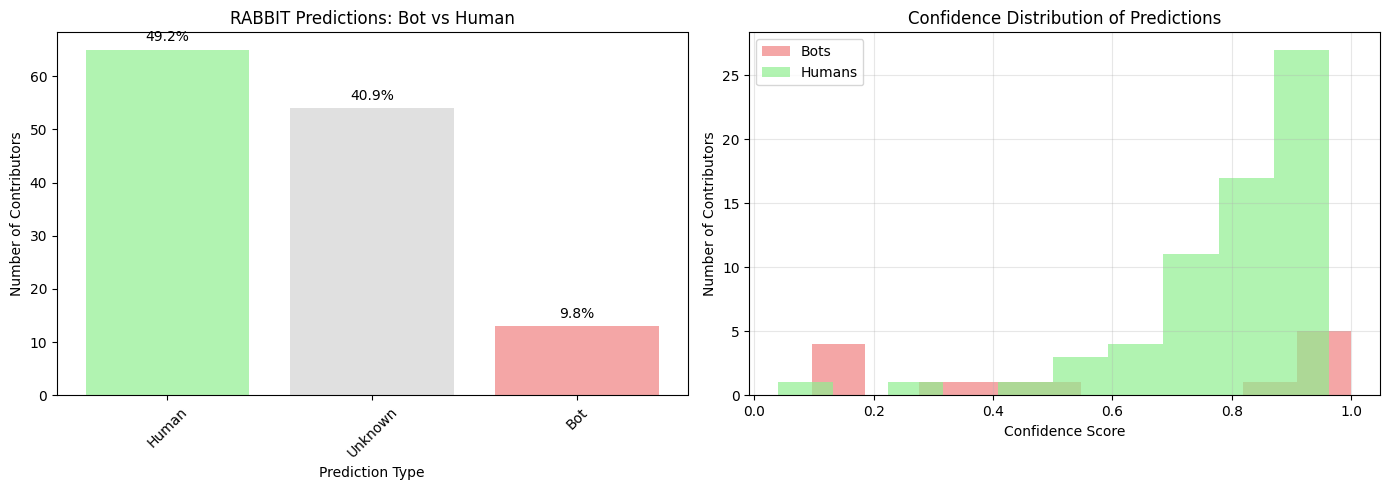

In [18]:
# Set up the visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Prediction type distribution
type_counts = rabbit_predictions['rabbit_type'].value_counts()
colors = {'Bot': 'lightcoral', 'Human': 'lightgreen', 'Unknown': 'lightgray', 'Error': 'orange'}
type_colors = [colors.get(t, 'gray') for t in type_counts.index]

axes[0].bar(type_counts.index, type_counts.values, color=type_colors, alpha=0.7)
axes[0].set_title('RABBIT Predictions: Bot vs Human')
axes[0].set_xlabel('Prediction Type')
axes[0].set_ylabel('Number of Contributors')
axes[0].tick_params(axis='x', rotation=45)

# Add percentage labels on bars
for i, (index, value) in enumerate(type_counts.items()):
    percentage = (value / len(rabbit_predictions) * 100)
    axes[0].text(i, value + 1, f'{percentage:.1f}%', ha='center', va='bottom')

# Plot 2: Confidence distribution for Bot predictions
if 'confidence' in rabbit_predictions.columns:
    bot_predictions = rabbit_predictions[rabbit_predictions['rabbit_type'] == 'Bot']
    human_predictions = rabbit_predictions[rabbit_predictions['rabbit_type'] == 'Human']
    
    if not bot_predictions.empty:
        axes[1].hist(bot_predictions['confidence'], bins=10, alpha=0.7, color='lightcoral', label='Bots')
    if not human_predictions.empty:
        axes[1].hist(human_predictions['confidence'], bins=10, alpha=0.7, color='lightgreen', label='Humans')
    
    axes[1].set_title('Confidence Distribution of Predictions')
    axes[1].set_xlabel('Confidence Score')
    axes[1].set_ylabel('Number of Contributors')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Question 2.3:**  
Look at the confidence distribution plot. Do bots tend to have higher confidence scores than humans? What might this indicate about the model's ability to identify bots?

In my distribution plot, humans tend to have higher confidence scores than bots. Except few bots with a confidence of 1 (because there have [bot] at the end of their name). So maybe the model is trained to detect behaviors of humans.

### 2.3. Manual Validation: Inspecting Bot & Human Profiles

Machine learning models are not perfect and their predictions can be uncertain. To better understand the limitations of RABBIT, we will manually inspect the contributors for which the model is **least confident**, i.e., those with the lowest confidence scores among bots and humans. These ambiguous cases are the most interesting for manual validation, as they may reveal edge cases or misclassifications.

The function below selects the `n_samples` bots and `n_samples` humans (for the analysis KEEP n_samples = 5) with the **lowest confidence** (excluding `'Unknown'` and `'Error'`). You will then examine their GitHub profiles and activities to decide whether you agree with RABBIT.

In [19]:
def select_low_confidence_samples(predictions_df, n_samples=5):
    """
    Select the n_samples bots and n_samples humans with the lowest confidence scores
    for manual inspection. Excludes Unknown and Error types.
    
    Returns:
        DataFrame with up to 2*n_samples rows.
    """
    # Filter out Unknown and Error
    valid = predictions_df[predictions_df['rabbit_type'].isin(['Bot', 'Human'])]
    
    # Separate by type
    bots = valid[valid['rabbit_type'] == 'Bot'].nsmallest(n_samples, 'confidence')
    humans = valid[valid['rabbit_type'] == 'Human'].nsmallest(n_samples, 'confidence')
    
    # Combine and return
    samples = pd.concat([bots, humans], ignore_index=True)
    return samples

# Select low‑confidence bots and humans for manual inspection
low_conf_samples = select_low_confidence_samples(rabbit_predictions, n_samples=3)
print("👁️ LOW‑CONFIDENCE CONTRIBUTORS FOR MANUAL INSPECTION")
print("(These are the predictions where RABBIT is most uncertain.)")
print("-" * 60)
display(low_conf_samples)

👁️ LOW‑CONFIDENCE CONTRIBUTORS FOR MANUAL INSPECTION
(These are the predictions where RABBIT is most uncertain.)
------------------------------------------------------------


,contributor,rabbit_type,confidence
0,Fe-r-oz,Bot,0.096
1,mitchphillipson,Bot,0.104
2,dkapt,Bot,0.110
3,raghav20232023,Human,0.040
4,kands-code,Human,0.296
5,Afffaa,Human,0.437


Now, for each selected contributor, we will manually check their GitHub profile and recent activity. Use the generated guide below.

In [20]:
def generate_inspection_guide(contributor_name, rabbit_type, confidence):
    """
    Generate guidelines for manually inspecting a contributor.
    """
    print(f"\n🔍 MANUAL INSPECTION: {contributor_name}")
    print(f"   RABBIT Prediction: {rabbit_type} (confidence: {confidence:.3f})")
    print("-" * 50)
    
    print("1️⃣ OPEN THEIR GITHUB PROFILE:")
    print(f"   https://github.com/{contributor_name}")
    print("   Look for:")
    print("   - Bio/description")
    print("   - Organisation affiliations")
    print("   - Website links")
    print("   - [bot] in username?")
    
    print("\n2️⃣ CHECK THEIR RECENT ACTIVITY:")
    print(f"   https://github.com/{contributor_name}?tab=activity")
    print("   Look for patterns:")
    print("   - Regular, automated-looking activities")
    print("   - Human-like comments and interactions")
    print("   - Type of repositories they contribute to")
    
    print("\n3️⃣ EXAMINE THEIR EVENTS IN OUR DATASET:")
    print("   Load their event data and look for:")
    print("   - Repetitive patterns")
    print("   - Timing of activities (same time daily?)")
    print("   - Types of actions (only commits? only comments?)")
    
    print("\n4️⃣ DECIDE: BOT or HUMAN?")
    print("   Based on your inspection, would you agree with RABBIT?")
    print("   Why or why not?")
    print("-" * 50)

# Generate inspection guides for sample contributors
for _, row in low_conf_samples.iterrows():
    generate_inspection_guide(row['contributor'], row['rabbit_type'], row['confidence'])


🔍 MANUAL INSPECTION: Fe-r-oz
   RABBIT Prediction: Bot (confidence: 0.096)
--------------------------------------------------
1️⃣ OPEN THEIR GITHUB PROFILE:
   https://github.com/Fe-r-oz
   Look for:
   - Bio/description
   - Organisation affiliations
   - Website links
   - [bot] in username?

2️⃣ CHECK THEIR RECENT ACTIVITY:
   https://github.com/Fe-r-oz?tab=activity
   Look for patterns:
   - Regular, automated-looking activities
   - Human-like comments and interactions
   - Type of repositories they contribute to

3️⃣ EXAMINE THEIR EVENTS IN OUR DATASET:
   Load their event data and look for:
   - Repetitive patterns
   - Timing of activities (same time daily?)
   - Types of actions (only commits? only comments?)

4️⃣ DECIDE: BOT or HUMAN?
   Based on your inspection, would you agree with RABBIT?
   Why or why not?
--------------------------------------------------

🔍 MANUAL INSPECTION: mitchphillipson
   RABBIT Prediction: Bot (confidence: 0.104)
--------------------------------

**TODO 2.4:** Create a DataFrame called `manual_validation` with columns: `contributor`, `rabbit_prediction`, `manual_assessment`, `agreement`, `evidence`. Then, for each contributor you inspected, fill in your findings.

In [21]:
# TODO: Create and fill the manual validation DataFrame
manual_validation = pd.DataFrame(columns=[
    'contributor', 'rabbit_prediction', 'manual_assessment', 'agreement', 'evidence'
])

# Example (you will replace with actual data):
# manual_validation.loc[0] = ['dependabot[bot]', 'Bot', 'Bot', 'Yes', 'Username ends with [bot], auto comments on PRs']
manual_validation.loc[0] = ['Fe-r-oz', 'Bot', 'Human', 'No', 'A teacher, human‑like profile, email']
manual_validation.loc[1] = ['mitchphillipson', 'Bot', 'Human', 'No', 'A data scientist, human‑like profile, email']
manual_validation.loc[2] = ['dkapt', 'Bot', 'Bot', 'Yes', 'Prototype, a lot of follwing but no followers, profile picture']
manual_validation.loc[3] = ['raghav20232023', 'Human', 'Human', 'Yes', 'Biography, few activities']
manual_validation.loc[4] = ['kands-code', 'Human', 'Human', 'Yes', 'Name of the commit, description of the commit']
manual_validation.loc[4] = ['Afffaa', 'Human', 'Human', 'Yes', 'No contribution, biography']

display(manual_validation)

,contributor,rabbit_prediction,manual_assessment,agreement,evidence
0,Fe-r-oz,Bot,Human,No,"A teacher, human‑like profile, email"
1,mitchphillipson,Bot,Human,No,"A data scientist, human‑like profile, email"
2,dkapt,Bot,Bot,Yes,"Prototype, a lot of follwing but no followers,..."
3,raghav20232023,Human,Human,Yes,"Biography, few activities"
4,Afffaa,Human,Human,Yes,"No contribution, biography"


**Question 2.4:**  
Based on your manual inspection, how accurate do you think RABBIT is? Were there any surprises (e.g., a low‑confidence human that looked like a bot)? Explain.

The first and second persons seem to be humans whereas Rabbit thinks there are bot.
For the others, I tend to agree with Rabbit. So when there are few activities, Rabbit is not accurate. 

###  2.4. Merging Bot Predictions with Project Data

Now we combine the RABBIT predictions with the project event DataFrames we created in Section 1. This will allow us to analyse bot vs. human activity within each project.

In [22]:
def merge_predictions_with_projects(rabbit_predictions, project_dfs):
    """
    Merge RABBIT predictions with project event data.
    
    Args:
        rabbit_predictions: DataFrame with RABBIT predictions
        project_dfs: Dictionary of project DataFrames
        
    Returns:
        Dictionary of merged DataFrames for each project
    """
    merged_data = {}
    
    for project_name, project_df in project_dfs.items():
        # Extract unique contributors from this project
        project_contributors = project_df['actor.login'].unique()
        
        # Filter RABBIT predictions for contributors in this project
        project_predictions = rabbit_predictions[
            rabbit_predictions['contributor'].isin(project_contributors)
        ].copy()
        
        print(f"\n📊 Project: {project_name}")
        print(f"  Unique contributors in project: {len(project_contributors)}")
        print(f"  Contributors with RABBIT predictions: {len(project_predictions)}")
        
        if not project_predictions.empty:
            # Add prediction information to project events
            prediction_dict = project_predictions.set_index('contributor').to_dict(orient='index')
            
            # Create new columns in project DataFrame
            project_df['rabbit_type'] = project_df['actor.login'].map(
                lambda x: prediction_dict.get(x, {}).get('rabbit_type', 'Unknown')
            )
            project_df['rabbit_confidence'] = project_df['actor.login'].map(
                lambda x: prediction_dict.get(x, {}).get('confidence', 0.0)
            )
            
            merged_data[project_name] = project_df
            
            # Summary
            bot_count = (project_df['rabbit_type'] == 'Bot').sum()
            human_count = (project_df['rabbit_type'] == 'Human').sum()
            unknown_count = (project_df['rabbit_type'] == 'Unknown').sum()
            
            print(f"  Bot events: {bot_count}")
            print(f"  Human events: {human_count}")
            print(f"  Unknown events: {unknown_count}")
        
    return merged_data

# Merge predictions with projects
merged_projects = merge_predictions_with_projects(rabbit_predictions, project_dfs)


📊 Project: jump-dev_JuMP.jl
  Unique contributors in project: 79
  Contributors with RABBIT predictions: 79
  Bot events: 135
  Human events: 916
  Unknown events: 41

📊 Project: sunpy_sunpy
  Unique contributors in project: 54
  Contributors with RABBIT predictions: 54
  Bot events: 64
  Human events: 1102
  Unknown events: 20


In [23]:
# Display a sample of merged data
if merged_projects:
    first_project = list(merged_projects.keys())[0]
    print(f"\n📋 Sample of merged data for {first_project}:")
    display(merged_projects[first_project][['actor.login', 'type', 'rabbit_type', 'rabbit_confidence']].head(10))


📋 Sample of merged data for jump-dev_JuMP.jl:


,actor.login,type,rabbit_type,rabbit_confidence
0,odow,IssueCommentEvent,Human,0.774
1,odow,IssuesEvent,Human,0.774
2,MRuzzante,WatchEvent,Unknown,0.000
3,odow,IssueCommentEvent,Human,0.774
4,odow,IssuesEvent,Human,0.774
5,odow,IssueCommentEvent,Human,0.774
6,jd-lara,IssueCommentEvent,Human,0.902
7,odow,IssueCommentEvent,Human,0.774
8,haansn08,IssuesEvent,Unknown,0.000
9,jd-lara,IssueCommentEvent,Human,0.902


**Question 2.5:**  
Look at the bot event percentages for each project. Which project has a higher proportion of bot activity? Does this match your expectation from Section 1? Why might one project rely more on bots?

The first project has a higher proportion of bot activity. This match my exceptation from Section 1. A project might rely on more bots if there are repetitive tasks to do, to perform security/code analysis?

Finally, we compare the types of activities performed by bots and humans in each project.

In [24]:
def analyse_bot_vs_human_activity(merged_project_df, project_name):
    """
    Compare activity patterns between bots and humans.
    """
    print(f"\n🔬 BOT VS HUMAN ANALYSIS: {project_name}")
    print("-" * 50)
    
    # Separate bot and human events
    bot_events = merged_project_df[merged_project_df['rabbit_type'] == 'Bot']
    human_events = merged_project_df[merged_project_df['rabbit_type'] == 'Human']
    
    print(f"Total events: {len(merged_project_df)}")
    print(f"Bot events: {len(bot_events)} ({len(bot_events)/len(merged_project_df)*100:.1f}%)")
    print(f"Human events: {len(human_events)} ({len(human_events)/len(merged_project_df)*100:.1f}%)")
    
    # Event type distribution comparison
    if not bot_events.empty:
        bot_event_types = bot_events['event_category'].value_counts()
        print(f"\n📊 Bot Event Categories:")
        for category, count in bot_event_types.items():
            percentage = (count / len(bot_events) * 100)
            print(f"  {category}: {count} events ({percentage:.1f}%)")
    
    if not human_events.empty:
        human_event_types = human_events['event_category'].value_counts()
        print(f"\n📊 Human Event Categories:")
        for category, count in human_event_types.items():
            percentage = (count / len(human_events) * 100)
            print(f"  {category}: {count} events ({percentage:.1f}%)")
    
    # Time analysis
    if not bot_events.empty and not human_events.empty:
        print(f"\n⏰ Activity Timing:")
        print(f"  Bot activity period: {bot_events['created_at'].min().date()} to {bot_events['created_at'].max().date()}")
        print(f"  Human activity period: {human_events['created_at'].min().date()} to {human_events['created_at'].max().date()}")
    
    return bot_events, human_events

# Analyse each project
for project_name, project_df in merged_projects.items():
    bot_events, human_events = analyse_bot_vs_human_activity(project_df, project_name)


🔬 BOT VS HUMAN ANALYSIS: jump-dev_JuMP.jl
--------------------------------------------------
Total events: 1092
Bot events: 135 (12.4%)
Human events: 916 (83.9%)

📊 Bot Event Categories:
  Issues: 65 events (48.1%)
  Commits: 61 events (45.2%)
  Repository: 9 events (6.7%)

📊 Human Event Categories:
  Commits: 360 events (39.3%)
  Pull Requests: 295 events (32.2%)
  Repository: 145 events (15.8%)
  Issues: 116 events (12.7%)

⏰ Activity Timing:
  Bot activity period: 2024-09-02 to 2024-11-27
  Human activity period: 2024-09-01 to 2024-11-29

🔬 BOT VS HUMAN ANALYSIS: sunpy_sunpy
--------------------------------------------------
Total events: 1186
Bot events: 64 (5.4%)
Human events: 1102 (92.9%)

📊 Bot Event Categories:
  Pull Requests: 44 events (68.8%)
  Issues: 10 events (15.6%)
  Repository: 10 events (15.6%)

📊 Human Event Categories:
  Pull Requests: 777 events (70.5%)
  Issues: 214 events (19.4%)
  Commits: 78 events (7.1%)
  Repository: 33 events (3.0%)

⏰ Activity Timing:
  Bo

Now, let's visualise the differences for the first project.

/tmp/ipykernel_17469/2030213354.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data_to_plot, labels=labels)
/tmp/ipykernel_17469/2030213354.py:99: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gaxs/Documents/S4/Software Evolution/TP3/Software-Evolution-Practical-Bots/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


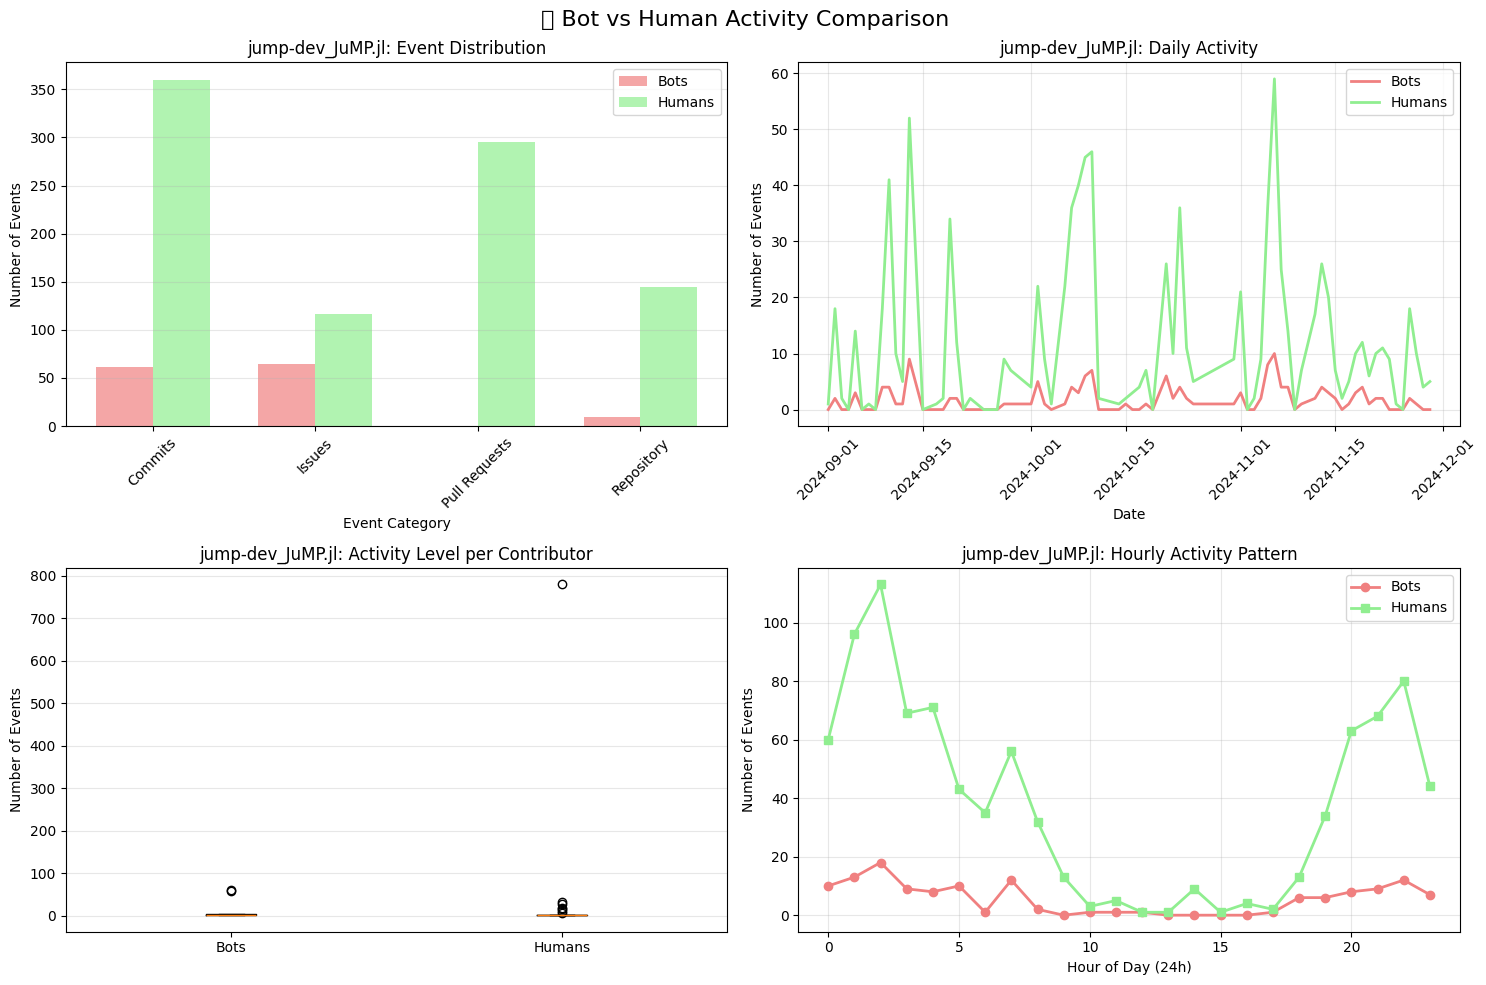

In [25]:
# Set up comparison visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🤖 Bot vs Human Activity Comparison', fontsize=16)

# Plot 1: Event category comparison for Project 1
project1_name = list(merged_projects.keys())[0]
project1_df = merged_projects[project1_name]

if not project1_df.empty:
    # Get category distribution for bots and humans
    bot_categories = project1_df[project1_df['rabbit_type'] == 'Bot']['event_category'].value_counts()
    human_categories = project1_df[project1_df['rabbit_type'] == 'Human']['event_category'].value_counts()
    
    # Create combined DataFrame for comparison
    categories = sorted(set(bot_categories.index) | set(human_categories.index))
    comparison_data = []
    
    for category in categories:
        comparison_data.append({
            'Category': category,
            'Bot': bot_categories.get(category, 0),
            'Human': human_categories.get(category, 0)
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Plot grouped bar chart
    x = np.arange(len(comparison_df))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, comparison_df['Bot'], width, label='Bots', color='lightcoral', alpha=0.7)
    axes[0, 0].bar(x + width/2, comparison_df['Human'], width, label='Humans', color='lightgreen', alpha=0.7)
    
    axes[0, 0].set_xlabel('Event Category')
    axes[0, 0].set_ylabel('Number of Events')
    axes[0, 0].set_title(f'{project1_name}: Event Distribution')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(comparison_df['Category'], rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Daily activity comparison
if not project1_df.empty:
    # Group by date and type
    project1_df['date'] = project1_df['created_at'].dt.date
    daily_activity = project1_df.groupby(['date', 'rabbit_type']).size().unstack(fill_value=0)
    
    if 'Bot' in daily_activity.columns and 'Human' in daily_activity.columns:
        axes[0, 1].plot(daily_activity.index, daily_activity['Bot'], label='Bots', color='lightcoral', linewidth=2)
        axes[0, 1].plot(daily_activity.index, daily_activity['Human'], label='Humans', color='lightgreen', linewidth=2)
        axes[0, 1].set_xlabel('Date')
        axes[0, 1].set_ylabel('Number of Events')
        axes[0, 1].set_title(f'{project1_name}: Daily Activity')
        axes[0, 1].legend()
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Contributor activity levels
if not project1_df.empty:
    # Calculate events per contributor
    contributor_activity = project1_df.groupby(['actor.login', 'rabbit_type']).size().reset_index(name='event_count')
    
    # Separate bots and humans
    bot_contributors = contributor_activity[contributor_activity['rabbit_type'] == 'Bot']
    human_contributors = contributor_activity[contributor_activity['rabbit_type'] == 'Human']
    
    # Create box plot
    data_to_plot = []
    labels = []
    
    if not bot_contributors.empty:
        data_to_plot.append(bot_contributors['event_count'].values)
        labels.append('Bots')
    
    if not human_contributors.empty:
        data_to_plot.append(human_contributors['event_count'].values)
        labels.append('Humans')
    
    if data_to_plot:
        axes[1, 0].boxplot(data_to_plot, labels=labels)
        axes[1, 0].set_ylabel('Number of Events')
        axes[1, 0].set_title(f'{project1_name}: Activity Level per Contributor')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Hourly activity patterns
if not project1_df.empty:
    project1_df['hour'] = project1_df['created_at'].dt.hour
    hourly_activity = project1_df.groupby(['hour', 'rabbit_type']).size().unstack(fill_value=0)
    
    if 'Bot' in hourly_activity.columns and 'Human' in hourly_activity.columns:
        axes[1, 1].plot(hourly_activity.index, hourly_activity['Bot'], label='Bots', color='lightcoral', linewidth=2, marker='o')
        axes[1, 1].plot(hourly_activity.index, hourly_activity['Human'], label='Humans', color='lightgreen', linewidth=2, marker='s')
        axes[1, 1].set_xlabel('Hour of Day (24h)')
        axes[1, 1].set_ylabel('Number of Events')
        axes[1, 1].set_title(f'{project1_name}: Hourly Activity Pattern')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Question 2.6:**  
Based on the bar chart, which event categories are dominated by bots? Which are mostly human? What does this tell you about the typical tasks that bots automate in this project?

The events dominated by bots are commits and issues. Bots can process issues and possibly propose a fix. But pull requests or repository operations are almost exclusively performed by humans. This makes sense, as these are crucial steps that can compromise the project if a bot does something wrong. 

## Section 3: Contributor Role Categorisation

In Section 2, we identified which contributors are bots using RABBIT. Now we will go a step further and examine **what** these contributors actually do in the project. By analysing their activities, we can assign them behavioral roles such as *developer*, *reviewer*, *reporter*, etc. This will allow us to compare bots and humans at a much finer granularity: do bots tend to specialise in certain roles? Are humans more diverse? How does the distribution of roles differ between the two projects?

### 3.1. Defining Roles from Project-Events

The roles we use are based on established software engineering research. They are defined as follows:

| **_Role_**    | **_Description_**                                                               |
|---------------|---------------------------------------------------------------------------------|
| **developer** | Pushed commits, opened a pull request or commented on their own pull request   |
| **reviewer**  | Reviewed a pull request or commented on a pull request review (by someone else) |
| **merger**    | Merged a pull request                                                           |
| **reporter**  | Opened an issue or commented on their own issue                                 |
| **commenter** | Commented on an issue opened by someone else                                    |
| **reactor**   | Reacted to content (requires additional API data, not available in our dataset) |

These roles are **not mutually exclusive**: a contributor can be both a developer and a reviewer in the same project and the counts for each role accumulate over time. For example, if a contributor opens 3 pull requests and reviews 2 pull requests, they will have `developer = 3` and `reviewer = 2`.

The input data for this analysis are the **activity sequences** stored in the `Project-Activities/` folder. Each line in these `.jsonl` files represents a single *activity*, a higher‑level abstraction of GitHub events (e.g., `OpenIssue`, `ReviewPullRequest`). The activities are already enriched with context (e.g., whether a comment was on one’s own issue or someone else’s), which enables the role assignment logic.

> 📁 **Data location**: `DATA_BASE_PATH / 'Project-Activities'` (the same base path you set in Section 1 & 2).

First, let's locate the activity files and load them into DataFrames.

In [26]:
ACTIVITIES_PATH = DATA_BASE_PATH / 'Project-Activities'

# List the activity files
activity_files = list(ACTIVITIES_PATH.glob('*.jsonl'))
print(f"📂 Found {len(activity_files)} activity files:")
for f in activity_files:
    print(f"  - {f.name}")

📂 Found 2 activity files:
  - jump-dev_JuMP.jl.jsonl
  - sunpy_sunpy.jsonl


Now load each file. The files are in **JSON Lines** format, each line is a separate JSON object. We use `pd.read_json(..., lines=True)` to read them directly.

In [27]:
# Load activities for each project into a dictionary
activities_dfs = {}
for file in activity_files:
    project_name = file.stem  # e.g., 'cupy_cupy'
    df = pd.read_json(file, lines=True)
    activities_dfs[project_name] = df
    print(f"\n✅ Loaded {len(df)} activities for {project_name}")
    print(f"   Sample columns: {list(df.columns)}")


✅ Loaded 865 activities for jump-dev_JuMP.jl
   Sample columns: ['activity', 'start_date', 'end_date', 'actor', 'repository', 'actions']

✅ Loaded 668 activities for sunpy_sunpy
   Sample columns: ['activity', 'start_date', 'end_date', 'actor', 'repository', 'actions']


**TODO 3.1:** In the cell below, write a short loop to display the **first 2 rows** of the activity DataFrame for one of the projects. This will help you see the structure of an activity record.

In [54]:
# TODO: Display the first 2 rows of an activity DataFrame (choose any project)
print(activities_dfs[PROJECT_1_NAME].head(2))

             activity            start_date              end_date  \
0  CommentPullRequest  2024-09-01T13:53:07Z  2024-09-01T13:53:07Z   
1      ManageBranches  2024-09-02T00:04:20Z  2024-09-02T00:04:20Z   

                                   actor  \
0  {'id': 12887482, 'login': 'datejada'}   
1       {'id': 8177701, 'login': 'odow'}   

                                          repository  \
0  {'id': 6150069, 'name': 'jump-dev/JuMP.jl', 'o...   
1  {'id': 6150069, 'name': 'jump-dev/JuMP.jl', 'o...   

                                             actions  
0  [{'action': 'CreatePullRequestComment', 'event...  
1  [{'action': 'CreateBranch', 'event_id': '41529...  


**Question 3.1:**  
Look at the columns of the activity DataFrame. What information does each activity contain? Why is it important that the `actor` and `repository` are stored as dictionaries rather than simple strings?

Each activity contains a start date, an end date, a dictionary of actors and a dictionary of repository and a dictionary of actions.  It is important that the actor are stored as dictionaries because it can have several actors on one activity, and each actor has metadata (id, login). It's the same thing for repository. We need to distinguish the ID to the name.

### 3.2. Assigning Roles: Developer, Reviewer, Reporter, etc.

We will now use the `roles` module (provided in the repository) to assign role counts to every contributor. The function `roles.assign()` expects a DataFrame with the same structure as the ones we just loaded and returns a new DataFrame with one row per contributor and columns for each role count.

In [55]:
# Import the role assignment module
import roles

role_dfs = {}

for project_name, df_act in activities_dfs.items():
    print(f"\n🔧 Assigning roles for {project_name} ...")

    df_roles = roles.assign(df_act)

    role_dfs[project_name] = df_roles
    print(f"   Found {len(df_roles)} distinct contributors.")
    print(f"   Role counts (sum over all contributors):")
    role_sums = df_roles[['developer','reviewer','merger','reporter','commenter','reactor']].sum()
    print(role_sums.to_string())


🔧 Assigning roles for jump-dev_JuMP.jl ...
   Found 79 distinct contributors.
   Role counts (sum over all contributors):
developer    443
reviewer      30
merger        59
reporter      37
commenter     26
reactor        0

🔧 Assigning roles for sunpy_sunpy ...
   Found 54 distinct contributors.
   Role counts (sum over all contributors):
developer    154
reviewer     164
merger        62
reporter      23
commenter     44
reactor        0


**TODO 3.2:** After running the cell above, compute the **average number of developer actions per contributor** for each project. Use the `role_dfs` dictionary. Print the results.

In [56]:
# TODO: Compute and print average developer count per project
for project_name, df_roles in role_dfs.items():
    avg_developers = df_roles['developer'].mean()
    print(f"Average number of developer actions for {project_name}: {avg_developers:.2f}")

Average developer count for jump-dev_JuMP.jl: 5.61
Average developer count for sunpy_sunpy: 2.85


**Question 3.2:**  
Look at the role totals printed above. Which role has the highest total count in each project? Which role has the lowest? What might this tell you about the development workflow of each project?

In the first project, the role with the highest total count is developper and reactor is with the lowest. In the second project, the role with the highest total count is reviewer and reactor is with the lowest. There are more reviews on the second project.

### 3.3. Visualising Role Distributions per Project

Now we visualise how roles are distributed. First, we look at **role presence**: how many contributors performed each role at least once.

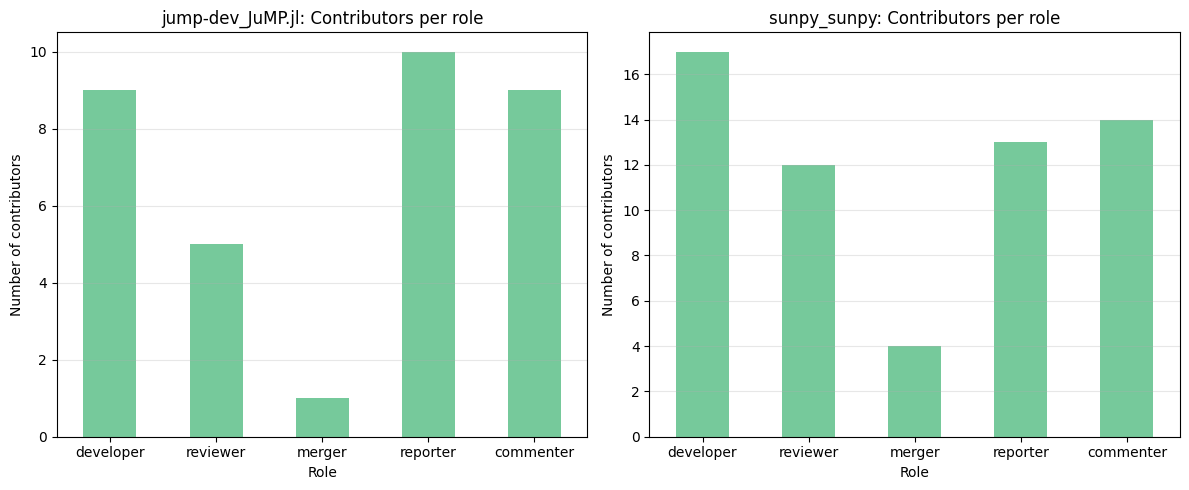

In [57]:
def plot_role_presence(role_df, project_name, ax):
    """Plot the number of contributors who have at least one occurrence of each role."""
    # Count non-zero entries for each role
    presence = (role_df[['developer','reviewer','merger','reporter','commenter']] > 0).sum()
    
    presence.plot(kind='bar', ax=ax, color='mediumseagreen', alpha=0.7)
    ax.set_title(f'{project_name}: Contributors per role')
    ax.set_ylabel('Number of contributors')
    ax.set_xlabel('Role')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (proj, df_roles) in enumerate(role_dfs.items()):
    plot_role_presence(df_roles, proj, axes[i])
plt.tight_layout()
plt.show()

Second, we look at **role intensity**: the total number of activities for each role (summed over all contributors).

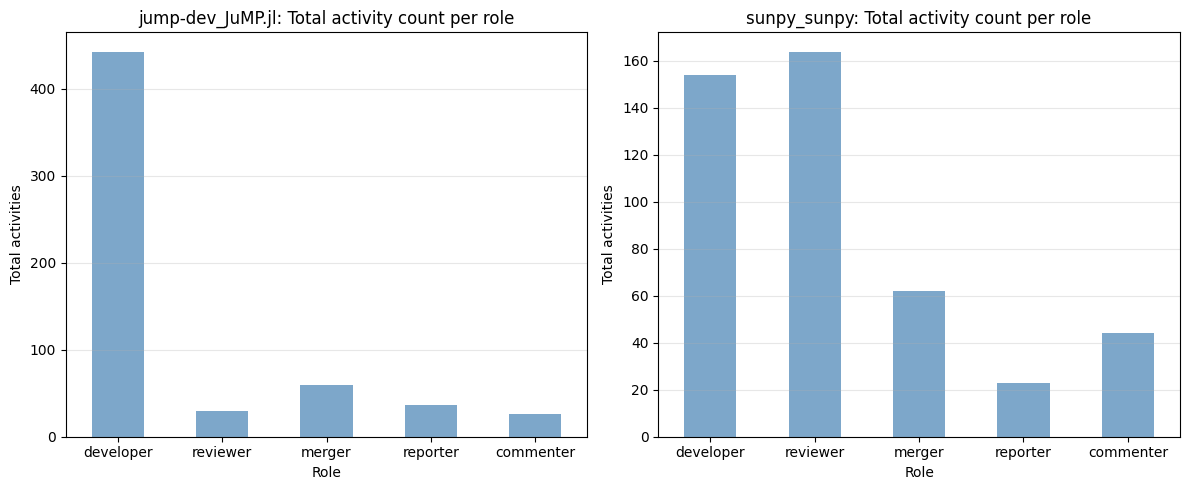

In [58]:
def plot_role_intensity(role_df, project_name, ax):
    """Plot the total number of role-related activities (sum over all contributors)."""
    totals = role_df[['developer','reviewer','merger','reporter','commenter']].sum()
    
    totals.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{project_name}: Total activity count per role')
    ax.set_ylabel('Total activities')
    ax.set_xlabel('Role')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (proj, df_roles) in enumerate(role_dfs.items()):
    plot_role_intensity(df_roles, proj, axes[i])
plt.tight_layout()
plt.show()

**Question 3.3:**  
Compare the two plots for each project. Are there roles that have many contributors but relatively few total activities? What about roles with few contributors but many activities? What might explain these patterns (e.g., some roles are performed occasionally by many, others intensively by a few)?

Roles like Developer (in JuMP.jl) and Reviewer (in SunPy) show intensive activity, likely driven by a small team.

In contrast, roles like Reporter and Commenter show much lower total activity, as these tasks are typically performed by the community.

### 3.4. Combining Roles with Bot/Human Labels

Now we combine the role data with the RABBIT predictions we obtained in Section 2. This will allow us to compare the behavior of bots and humans.

First, ensure that `rabbit_predictions` is available. If you need to reload it, uncomment the appropriate line.

In [59]:
# If Section 2 ran successfully, RABBIT predictions are already stored in `rabbit_predictions`.
# Otherwise, load them from DATA_BASE_PATH / 'User_Types.csv' (already prepared for you if needed).

print("🐇 RABBIT predictions preview:")
display(rabbit_predictions.head())

🐇 RABBIT predictions preview:


,contributor,rabbit_type,confidence
0,Fe-r-oz,Bot,0.096
1,QuantPaul,Human,0.784
2,dong123-wang,Unknown,0.000
3,aditya-mathpal,Unknown,0.000
4,sstroemer,Human,0.771


Now merge each project's role DataFrame with the predictions.

In [60]:
# Merge role data with rabbit_type
role_with_labels = {}
for proj, df_roles in role_dfs.items():
    # Left join: keep all roles rows, add rabbit_type where available
    merged = df_roles.merge(rabbit_predictions[['contributor', 'rabbit_type', 'confidence']], 
                            on='contributor', how='left')
    # Fill missing rabbit_type with 'Unknown'
    merged['rabbit_type'] = merged['rabbit_type'].fillna('Unknown')
    role_with_labels[proj] = merged
    
    print(f"\n{proj}:")
    print(merged['rabbit_type'].value_counts(dropna=False))
    print(merged.head())


jump-dev_JuMP.jl:
rabbit_type
Unknown    37
Human      32
Bot        10
Name: count, dtype: int64
  contributor           project  developer  reviewer  merger  reporter  \
0      Afffaa  jump-dev/JuMP.jl          0         0       0         0   
1   Akshit222  jump-dev/JuMP.jl          2         0       0         0   
2   Andrij339  jump-dev/JuMP.jl          0         0       0         0   
3    Bunnie04  jump-dev/JuMP.jl          0         0       0         0   
4     Fe-r-oz  jump-dev/JuMP.jl          0         0       0         0   

   commenter  reactor rabbit_type  confidence  
0          0        0       Human       0.437  
1          1        0     Unknown       0.000  
2          0        0     Unknown       0.000  
3          0        0     Unknown       0.000  
4          0        0         Bot       0.096  

sunpy_sunpy:
rabbit_type
Human      33
Unknown    17
Bot         4
Name: count, dtype: int64
    contributor      project  developer  reviewer  merger  reporter  \
0  

**TODO 3.3:** For the first project, calculate the **median** number of developer actions for bots and for humans separately. (Use `.median()` instead of `.mean()`.) Print both values.

In [75]:
# TODO: Compute median developer count for bots and humans in the first project
project1_roles = role_with_labels[PROJECT_1_NAME]
#print(project1_roles)
median_devs_bots = project1_roles[project1_roles['rabbit_type'] == 'Bot']['developer'].median()
print(f"Median developer count for Bots in {PROJECT_1_NAME}: {median_devs_bots}")

median_devs_humans = project1_roles[project1_roles['rabbit_type'] == 'Human']['developer'].median()
print(f"Median developer count for Humans in {PROJECT_1_NAME}: {median_devs_humans}")

     contributor           project  developer  reviewer  merger  reporter  \
0         Afffaa  jump-dev/JuMP.jl          0         0       0         0   
1      Akshit222  jump-dev/JuMP.jl          2         0       0         0   
2      Andrij339  jump-dev/JuMP.jl          0         0       0         0   
3       Bunnie04  jump-dev/JuMP.jl          0         0       0         0   
4        Fe-r-oz  jump-dev/JuMP.jl          0         0       0         0   
..           ...               ...        ...       ...     ...       ...   
74       wsmoses  jump-dev/JuMP.jl          2         2       0         0   
75     yrbnr7034  jump-dev/JuMP.jl          0         0       0         0   
76  zelenkastiot  jump-dev/JuMP.jl          0         0       0         0   
77       zinccat  jump-dev/JuMP.jl          0         0       0         0   
78       zyk1999  jump-dev/JuMP.jl          0         0       0         0   

    commenter  reactor rabbit_type  confidence  
0           0        0    

**Question 3.4:**  
Look at the value counts printed above. How many contributors in each project have an `'Unknown'` rabbit_type? Why are they unknown? (Hint: recall which contributors RABBIT analysed.)

There are 37 Unknown persons on the first project and 17 for the second. They are unknown because they have not enough activities. 

We can now compare the average (mean) role counts for bots and humans. This tells us what a “typical” bot does versus a typical human.

In [74]:
def compare_bot_human_roles(merged_df, project_name):
    """Compute mean role counts for bots and humans."""
    grouped = merged_df.groupby('rabbit_type')[['developer','reviewer','merger','reporter','commenter']].mean()
    return grouped

for proj, df in role_with_labels.items():
    print(f"\n📊 {proj} - Average role activities per contributor type")
    display(compare_bot_human_roles(df, proj))


📊 jump-dev_JuMP.jl - Average role activities per contributor type


,developer,reviewer,merger,reporter,commenter
rabbit_type,,,,,
Bot,5.700000,0.0000,0.00000,0.600000,0.100000
Human,12.000000,0.9375,1.84375,0.875000,0.750000
Unknown,0.054054,0.0000,0.00000,0.081081,0.027027



📊 sunpy_sunpy - Average role activities per contributor type


,developer,reviewer,merger,reporter,commenter
rabbit_type,,,,,
Bot,8.250000,0.250000,0.000000,0.000000,0.000000
Human,3.666667,4.939394,1.878788,0.666667,1.303030
Unknown,0.000000,0.000000,0.000000,0.058824,0.058824


**TODO 3.4:** Write a few lines of code to extract the mean values for bots in the second project and print them in a formatted way (e.g., `"Developer: 2.6, Reviewer: 0.0, ..."`).

In [76]:
# TODO: Extract and print bot mean values for the second project
project2_roles = role_with_labels[PROJECT_2_NAME]
bot_means = project2_roles[project2_roles['rabbit_type'] == 'Bot'][['developer','reviewer','merger','reporter','commenter']].mean()
print(f"\nAverage role activities for Bots in {PROJECT_2_NAME}:")
print(bot_means)



Average role activities for Bots in sunpy_sunpy:
developer    8.25
reviewer     0.25
merger       0.00
reporter     0.00
commenter    0.00
dtype: float64


Now let's visualise these differences with grouped bar charts.

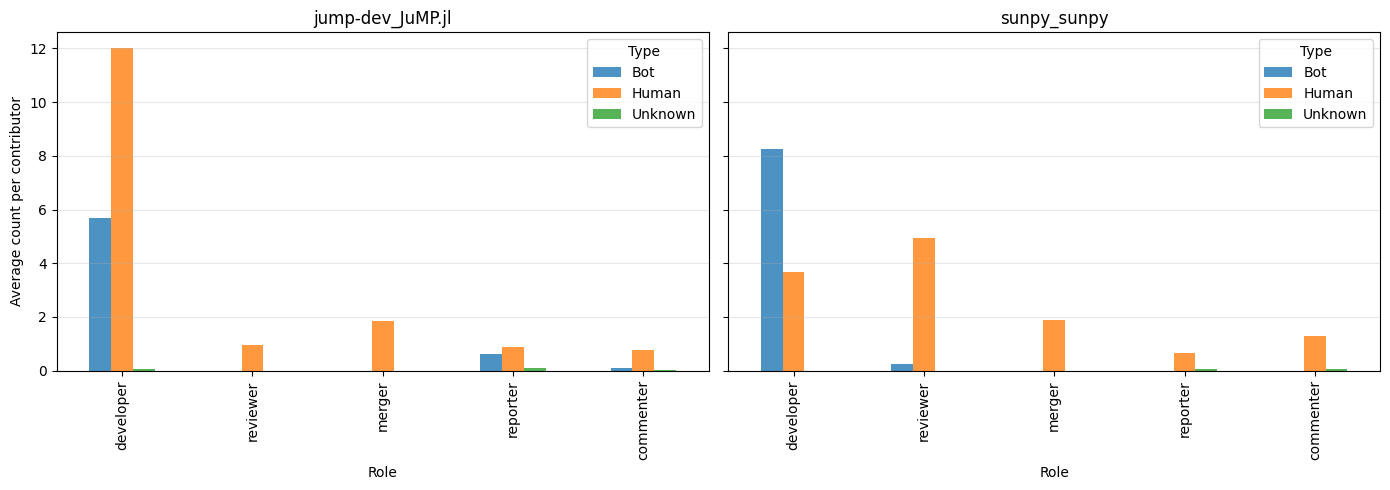

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (proj, df) in enumerate(role_with_labels.items()):
    # Prepare data: mean per role, split by rabbit_type
    means = df.groupby('rabbit_type')[['developer','reviewer','merger','reporter','commenter']].mean().T
    
    # Plot
    means.plot(kind='bar', ax=axes[idx], alpha=0.8)
    axes[idx].set_title(proj)
    axes[idx].set_xlabel('Role')
    axes[idx].set_ylabel('Average count per contributor')
    axes[idx].legend(title='Type')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Question 3.5:**  
Examine the bar charts. In which project do bots show the most specialised behaviour (i.e., high average in a few roles, near zero in others)? Which roles do bots dominate? What does this suggest about the purpose of bots in each project?

It is in the second project that the bots show the most specialised behaviour high average in a few roles, near zero in others. Bots dominate developer actions. The bots have each a specific purpose.

## Section 4: Comparative Behavioral Analysis

In this final section, we bring together everything we have learned about the two projects, their contributors and the roles they play. Our goal is to compare:

- The overall **behavioral profiles** of each project.
- How **bots and humans** differ in their activities.
- The **differences between the two projects** and possible explanations.
- Whether observed differences are **statistically significant**.

By the end, you will have a comprehensive understanding of how bots and humans collaborate (or not) in these open‑source projects and what factors might shape their behavior.

### 4.1. Profiling Contributor Behavior per Project

First, let’s build a high‑level picture of each project’s contributor activity. We’ll use the data we have prepared:
- **Event categories** (from Section 1), e.g., Issues, Pull Requests, Commits, Repository events.
- **Role counts** (from Section 3), e.g., how many times contributors acted as developers, reviewers, etc.

Run the cell below to see a quick summary of each project’s events.

In [94]:
# Assuming we have:
#   - project_dfs: dict of DataFrames with project events (from Section 1)
#   - role_with_labels: dict of DataFrames with role counts per contributor + rabbit_type (from Section 3)

for proj_name, df_events in project_dfs.items():
    print(f"\n📊 PROJECT: {proj_name}")
    print("-" * 50)
    print(f"Total events: {len(df_events)}")
    print(f"Unique contributors: {df_events['actor.login'].nunique()}")
    print(f"Time span: {df_events['created_at'].min().date()} to {df_events['created_at'].max().date()}")
    
    # Event category distribution
    cat_counts = df_events['event_category'].value_counts()
    print("\nEvent categories:")
    for cat, count in cat_counts.items():
        print(f"  {cat}: {count} ({count/len(df_events)*100:.1f}%)")


📊 PROJECT: jump-dev_JuMP.jl
--------------------------------------------------
Total events: 1092
Unique contributors: 79
Time span: 2024-09-01 to 2024-11-29

Event categories:
  Commits: 421 (38.6%)
  Pull Requests: 297 (27.2%)
  Repository: 189 (17.3%)
  Issues: 185 (16.9%)

📊 PROJECT: sunpy_sunpy
--------------------------------------------------
Total events: 1186
Unique contributors: 54
Time span: 2024-09-01 to 2024-11-30

Event categories:
  Pull Requests: 821 (69.2%)
  Issues: 226 (19.1%)
  Commits: 78 (6.6%)
  Repository: 61 (5.1%)


**TODO 4.1:** Compute the **average number of events per contributor** for each project (total events divided by unique contributors). Print the values and comment on which project has a higher average.

In [95]:
# TODO: Compute and print average events per contributor for each project.
for project_name in [PROJECT_1_NAME, PROJECT_2_NAME]:
    df = project_dfs[project_name]
    events_per_contributor = df.groupby('actor.login').size()
    avg_events = events_per_contributor.mean()
    print(f"Average events per contributor for {project_name}: {avg_events:.2f}")

Average events per contributor for jump-dev_JuMP.jl: 13.82
Average events per contributor for sunpy_sunpy: 21.96


**Question 4.1:**  
Look at the event category distributions. Which project has a higher proportion of **Pull Request**‑related events? Which has more **Repository** events? What might this suggest about the type of work happening in each project?

The second project has the highest proportion of Pull Request. The first project has the most Repository events. It confirms our hypothesis.

Now let's examine the role distributions, how many contributors perform each role and how many activities they contribute.

In [96]:
def project_role_profile(role_df, project_name):
    """Print and visualise role profile for a project."""
    print(f"\n👥 Role profile for {project_name}:")
    # Number of contributors active in each role (at least one action)
    role_presence = (role_df[['developer','reviewer','merger','reporter','commenter']] > 0).sum()
    print("\nContributors involved in each role:")
    print(role_presence.to_string())
    
    # Total activities per role
    role_totals = role_df[['developer','reviewer','merger','reporter','commenter']].sum()
    print("\nTotal activities per role:")
    print(role_totals.to_string())
    
    return role_presence, role_totals

profiles = {}
for proj, df_role in role_with_labels.items():
    profiles[proj] = project_role_profile(df_role, proj)


👥 Role profile for jump-dev_JuMP.jl:

Contributors involved in each role:
developer     9
reviewer      5
merger        1
reporter     10
commenter     9

Total activities per role:
developer    443
reviewer      30
merger        59
reporter      37
commenter     26

👥 Role profile for sunpy_sunpy:

Contributors involved in each role:
developer    17
reviewer     12
merger        4
reporter     13
commenter    14

Total activities per role:
developer    154
reviewer     164
merger        62
reporter      23
commenter     44


**TODO 4.2:** For each project, calculate the **ratio of total reviewer activities to total developer activities**. Print both ratios. (e.g., `reviewer/developer`). If developer total is zero, print "N/A".

In [97]:
# TODO: Compute reviewer/developer ratio for each project.
for proj, df_role in role_with_labels.items():
    total_devs = df_role['developer'].sum()
    total_reviewers = df_role['reviewer'].sum()
    ratio = total_reviewers / total_devs if total_devs > 0 else float('inf')
    print(f"Reviewer/Developer ratio for {proj}: {ratio:.2f}")

Reviewer/Developer ratio for jump-dev_JuMP.jl: 0.07
Reviewer/Developer ratio for sunpy_sunpy: 1.06


**Question 4.2:**  
Which project has a higher reviewer‑to‑developer ratio? What might this indicate about the code review culture in that project (e.g., more thorough review, more reviewers per PR)?


The second project has the highest reviewer-to-developer ratio. The code is reviewed before merged (more thorough review, more reviewers per PR)?

### 4.2. Comparing Bots and Humans: Who Does What?

Now we separate contributors by their type (bot vs. human) and compare their activity within each project. We use the merged DataFrames `role_with_labels` that contain a `rabbit_type` column.

In [98]:
roles = ['developer', 'reviewer', 'merger', 'reporter', 'commenter']
projects = list(role_with_labels.keys())

def compare_bot_human_means(merged_df, project_name):
    grouped = merged_df.groupby('rabbit_type')[roles].mean()
    return grouped

for proj, df in role_with_labels.items():
    print(f"\n🤖 vs 🧑 {proj}")
    display(compare_bot_human_means(df, proj).round(2))


🤖 vs 🧑 jump-dev_JuMP.jl


,developer,reviewer,merger,reporter,commenter
rabbit_type,,,,,
Bot,5.70,0.00,0.00,0.60,0.10
Human,12.00,0.94,1.84,0.88,0.75
Unknown,0.05,0.00,0.00,0.08,0.03



🤖 vs 🧑 sunpy_sunpy


,developer,reviewer,merger,reporter,commenter
rabbit_type,,,,,
Bot,8.25,0.25,0.00,0.00,0.00
Human,3.67,4.94,1.88,0.67,1.30
Unknown,0.00,0.00,0.00,0.06,0.06


**TODO 4.3:** In the second project, compute the **median** (instead of mean) for each role for bots and humans. Use `.median()`. Print the results in a readable format.

In [99]:
# TODO: Compute median role counts for bots and humans in the second project.
project2_roles = role_with_labels[PROJECT_2_NAME]
median_bots = project2_roles[project2_roles['rabbit_type'] == 'Bot'][roles].median()
median_humans = project2_roles[project2_roles['rabbit_type'] == 'Human'][roles].median()
print(f"\nMedian role counts for Bots in {PROJECT_2_NAME}:")
print(median_bots)
print(f"\nMedian role counts for Humans in {PROJECT_2_NAME}:")
print(median_humans)


Median role counts for Bots in sunpy_sunpy:
developer    7.5
reviewer     0.0
merger       0.0
reporter     0.0
commenter    0.0
dtype: float64

Median role counts for Humans in sunpy_sunpy:
developer    0.0
reviewer     0.0
merger       0.0
reporter     0.0
commenter    0.0
dtype: float64


**Question 4.3:**  
Look at the mean tables. In which project do bots have a **higher** average for the `reporter` role than humans? What kinds of tasks might bots be automating as reporters (e.g., opening issues, commenting on own issues)?

As reporters, bots can opening issues (after performed an analysis) and can add comments.

Grouped bar charts give a quick visual comparison.

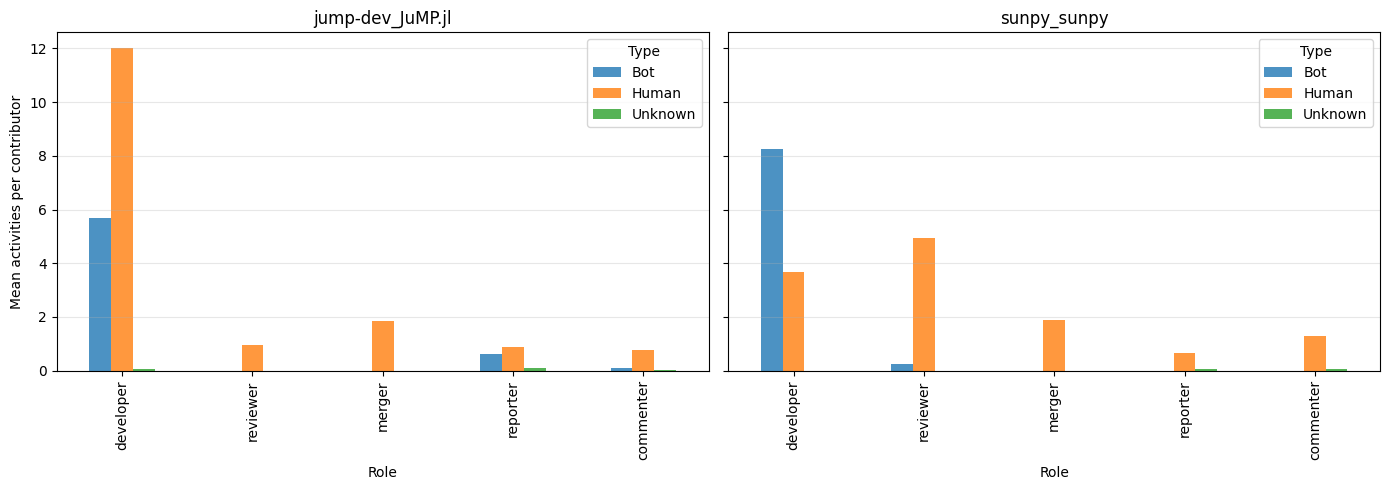

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for idx, (proj, df) in enumerate(role_with_labels.items()):
    means = df.groupby('rabbit_type')[roles].mean().T  # roles as rows, types as columns
    means.plot(kind='bar', ax=axes[idx], alpha=0.8)
    axes[idx].set_title(proj)
    axes[idx].set_xlabel('Role')
    axes[idx].set_ylabel('Mean activities per contributor')
    axes[idx].legend(title='Type')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Box plots show the full distribution (including outliers, exclude them when needed) and can reveal whether bots are more uniform.

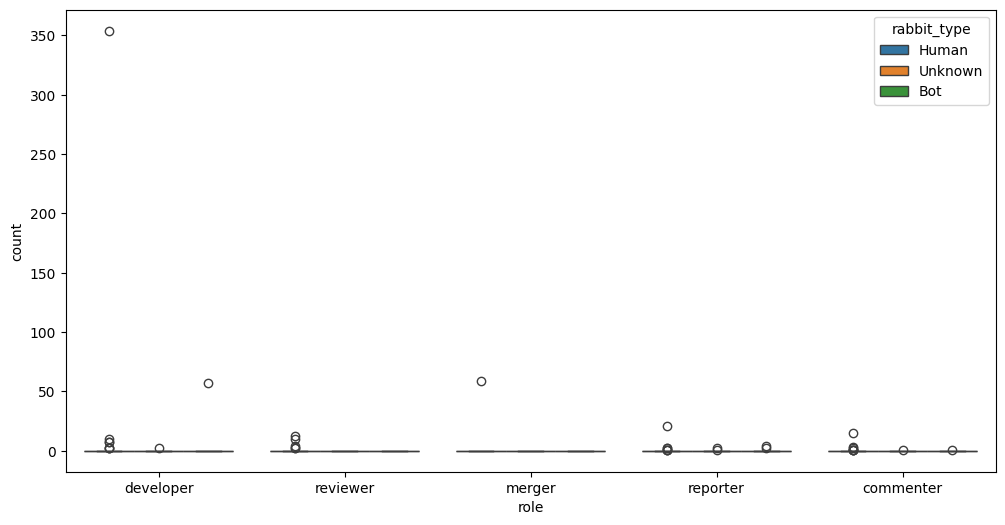

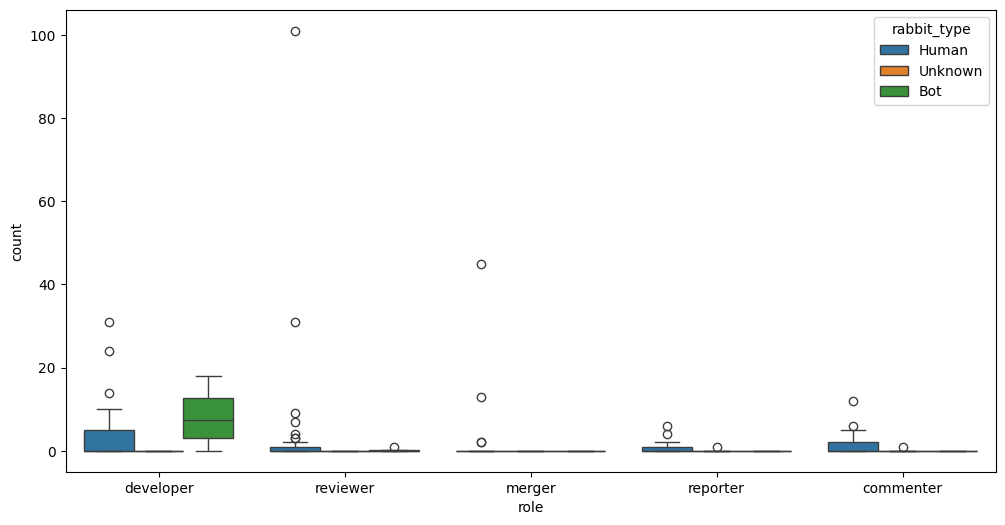

In [46]:
for proj, df in role_with_labels.items():
    # Melt the DataFrame to long format for seaborn
    df_melt = df.melt(id_vars=['contributor','rabbit_type'], 
                      value_vars=roles, 
                      var_name='role', value_name='count')
    
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df_melt, x='role', y='count', hue='rabbit_type')
    #plt.title(f'{proj} - Activity distribution per role by contributor type')
    #plt.yscale('log')  # because many zeros and large ranges
    #plt.grid(axis='y', alpha=0.3)
    plt.show()

**Question 4.4:**  
Examine the box plots. Do bots tend to have **less variability** (narrower boxes) than humans? Why might that be? Which role shows the most striking difference in variability between bots and humans?

Yes, bots generally tend to show less variability than humans in most roles, which is consistent with their more specialised and repetitive behavior. The most striking variability difference is the commenter role, where humans are much more spread out than bots.

### 4.3. Project-Level Differences: What Explains the Variation?

Now we directly compare the two projects to understand how they differ and hypothesise why.

**Quantify differences in bot presence and role distribution**

In [101]:
comparison = pd.DataFrame(index=[PROJECT_1_NAME, PROJECT_2_NAME])

for proj, df in role_with_labels.items():
    # Bot percentage among contributors
    bot_count = (df['rabbit_type'] == 'Bot').sum()
    total_contrib = len(df)
    comparison.loc[proj, 'Bot % (contributors)'] = f"{bot_count/total_contrib*100:.1f}%"
    
    # Bot percentage of total activities (sum of all roles)
    bot_activities = df[df['rabbit_type'] == 'Bot'][roles].sum().sum()
    total_activities = df[roles].sum().sum()
    comparison.loc[proj, 'Bot % (activities)'] = f"{bot_activities/total_activities*100:.1f}%"

display(comparison)

,Bot % (contributors),Bot % (activities)
jump-dev_JuMP.jl,12.7%,10.8%
sunpy_sunpy,7.4%,7.6%


**TODO 4.4:** Compute the **ratio of bot activity percentage to bot contributor percentage** for each project. This tells you whether bots are more or less active than their numbers suggest. Print both ratios.

In [103]:
# TODO: Compute (Bot % activities) / (Bot % contributors) for each project.
for proj in comparison.index:
    bot_contrib_pct = float(comparison.loc[proj, 'Bot % (contributors)'].rstrip('%'))
    bot_activity_pct = float(comparison.loc[proj, 'Bot % (activities)'].rstrip('%'))
    ratio = bot_activity_pct / bot_contrib_pct if bot_contrib_pct > 0 else float('inf')
    comparison.loc[proj, 'Activity/Contributor Ratio'] = f"{ratio:.2f}"

**Question 4.5:**  
In which project are bots **over‑represented** in terms of activity compared to their share of contributors? What does this imply about the intensity of bot activity in that project?

Does not apply here

**Compare role distributions** using a stacked bar chart of total activities (or contributor counts) split by type.

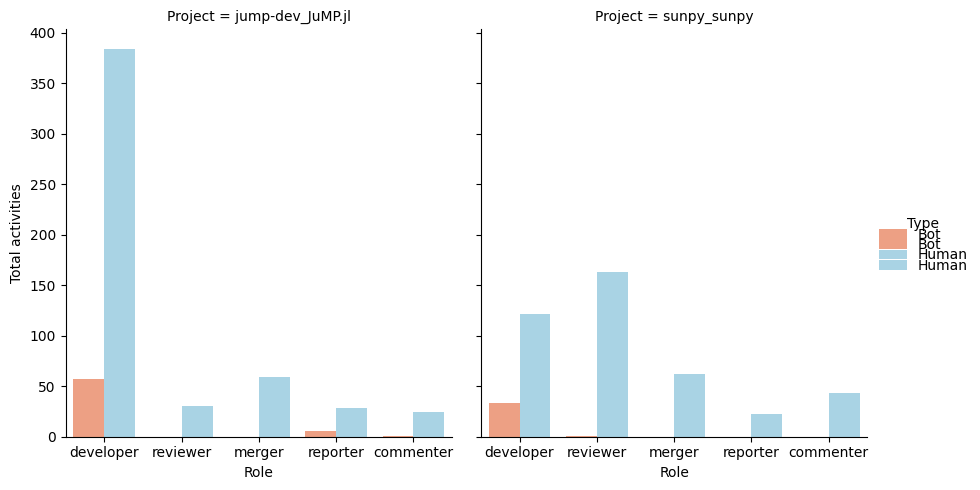

In [104]:
# Prepare data for stacked bars
stack_data = []
for proj in projects:
    df = role_with_labels[proj]
    for role in roles:
        for typ in ['Bot', 'Human']:
            val = df[df['rabbit_type']==typ][role].sum()
            stack_data.append({'Project': proj, 'Role': role, 'Type': typ, 'Activities': val})

stack_df = pd.DataFrame(stack_data)

# Plot stacked bars per project
g = sns.catplot(data=stack_df, kind='bar', x='Role', y='Activities', hue='Type', col='Project', 
                palette={'Bot':'coral','Human':'skyblue'}, alpha=0.8, height=5, aspect=0.8)
g.set_axis_labels('Role', 'Total activities')
g.add_legend()
plt.show()

**Question 4.6:**  
Look at the stacked bars. In which project do bots contribute a visible share of `developer` activities? In which project do they contribute most to `reporter`? Based on your knowledge of typical bot tasks (e.g., dependency updates, issue triage), do these patterns make sense?

Bots contribute most to reporter in the first project. In both projects they contribute a visible share of developer activities.

### 4.4. Statistical Validation and Key Takeaways

Finally, we check whether the observed differences are statistically meaningful and we summarise our main findings.

**Are bots and humans really different? (per project, per role)**

We use the **Mann‑Whitney U test** to compare the distributions of activity counts for each role between bots and humans. This test does not assume normality and is suitable for count data with many zeros.

In [50]:
from scipy.stats import mannwhitneyu

for proj in projects:
    df = role_with_labels[proj]
    bots = df[df['rabbit_type'] == 'Bot']
    humans = df[df['rabbit_type'] == 'Human']
    
    print(f"\n🔬 Statistical tests for {proj}")
    print("-" * 40)
    for role in roles:
        if len(bots) > 0 and len(humans) > 0:
            stat, p = mannwhitneyu(bots[role], humans[role], alternative='two-sided')
            print(f"{role:12s}: p = {p:.4f} {'(significant)' if p < 0.05 else '(not significant)'}")
        else:
            print(f"{role:12s}: insufficient data")


🔬 Statistical tests for jump-dev_JuMP.jl
----------------------------------------
developer   : p = 0.4903 (not significant)
reviewer    : p = 0.1983 (not significant)
merger      : p = 0.6149 (not significant)
reporter    : p = 0.8461 (not significant)
commenter   : p = 0.3880 (not significant)

🔬 Statistical tests for sunpy_sunpy
----------------------------------------
developer   : p = 0.1355 (not significant)
reviewer    : p = 0.5963 (not significant)
merger      : p = 0.4961 (not significant)
reporter    : p = 0.1639 (not significant)
commenter   : p = 0.1429 (not significant)


**TODO 4.5:** For any role where the p‑value is less than 0.05, compute the **mean difference** (bot mean minus human mean) to see the direction of the difference. Print a short summary.

In [ ]:
# TODO: For each significant role, compute and print bot_mean - human_mean.



**Question 4.7:**  
Interpret the statistical results. Are there any roles where bots and humans differ significantly? If yes, what does that tell you about the specialisation of bots? If no significant differences were found, does that mean bots and humans behave the same? Why might the test not detect differences even if means look different?

*Your answer here.*

**Are the two projects significantly different?**

We can compare, for example, the overall activity per contributor (total of all roles) between the two projects or the proportion of bot activity. A simple test: Mann‑Whitney on the total activity per contributor.

In [52]:
# Create a combined DataFrame with project identifier
combined = pd.concat([
    role_with_labels[proj].assign(project=proj) for proj in projects
], ignore_index=True)

# Compare total activity (sum of all roles) between projects
total_activity = combined[roles].sum(axis=1)
combined['total_activity'] = total_activity

proj1_data = combined[combined['project']==projects[0]]['total_activity']
proj2_data = combined[combined['project']==projects[1]]['total_activity']

stat, p = mannwhitneyu(proj1_data, proj2_data, alternative='two-sided')
print(f"Comparison of total activity per contributor between projects: p = {p:.4f}")

Comparison of total activity per contributor between projects: p = 0.0001


If `p < 0.05`, we conclude that the overall activity levels differ significantly between the two projects.

**Question 4.8:**  
Based on the p‑value, do the two projects have significantly different levels of contributor activity? What might explain this difference (e.g., project size, maturity, development phase)?

*Your answer here.*